# 08 — AOGS study: DEM shadowing + discrete-layer density (complete)

One notebook, the whole study.
**Part I (§1–6)** — terrain shadowing from the LOLA DEM and a first
fixed-boundary 3-layer ρ·c_p sensitivity (88 solves,
`aogs_sensitivity.json`).
**Part II (§7–15)** — the extensive density study (650 solves,
`aogs_density_study.json`): swept boundaries × cp/coupled branches,
then the follow-up analyses behind the poster (winner bootstrap,
pure-K_d check, terrain-radiation terms, geology + degeneracy).


**Goal (AOGS presentation).** Extend the letter's 1-D thermal model at the
Apollo 15 / 17 boreholes with two ingredients and test their leverage on
the stable-window deep-sensor fit:

1. **Terrain shadowing from the LOLA DEM** — the local horizon blocks the
   Sun near sunrise/sunset (Apollo 15 sits under the Apennine front;
   Apollo 17 inside the Taurus–Littrow valley), trimming the insolation.
2. **A discretized 3-layer density profile** — instead of the continuous
   Hayne ρ(z), three constant-density layers (surface < 10 cm,
   intermediate 10–50 cm, deep > 50 cm) whose densities are swept over
   literature-plausible values.

Every candidate is solved to **certified periodic equilibrium** with the
flux-anchored solver (custom `rho_func` + custom `insolation`; K(T,z)
held at each site's certified K_d\*) and scored by RMSE against the same
stable-window deep-sensor temperatures the letter uses.

**Architecture.** The physics ran once in
`code/pipeline/compute/aogs/s1_sensitivity.py` → `results/aogs_sensitivity.json`;
this notebook only reads that JSON and draws. Re-run the script to refresh.

**Honesty caveats** (also stored in the JSON meta): the 16 ppd DEM
(~1.9 km/px) resolves the Apennine front but undersamples the near-field
Taurus–Littrow massifs, so **A17 horizons are a lower bound**; densities
enter only through ρ·c_p (heat capacity) at fixed K, so small RMSE
spreads are themselves a finding.

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
from lunar._bootstrap import find_repo_root
from lunar.plotting.style import (JGR_FULL, C_A15, C_A17, C_HAYNE, C_CHAR,
                                  C_GRID, C_TEAL, fmt_axis, assert_no_overlap)
ROOT = find_repo_root()
d = json.loads((ROOT/"results"/"aogs_sensitivity.json").read_text())
meta, sites = d["meta"], d["sites"]
runs = d["runs"]
SITE_COLOR = {"A15": C_A15, "A17": C_A17}
print("runs:", len(runs), "| DEM:", meta["dem_ppd"], "ppd |",
      "combos: L1", meta["rho_l1"], "L2", meta["rho_l2"], "L3", meta["rho_l3"])
print("certification (best combo, n_inner 24 vs 96):")
for s,c in d["certification"].items():
    print(f"  {s}: {c['best_profile']}  RMSE {c['rmse_sweep']:.3f} vs {c['rmse_n96']:.3f} K  (drift {c['drift_K']*1000:.1f} mK)")

runs: 88 | DEM: 16 ppd | combos: L1 [1100.0, 1300.0, 1500.0] L2 [1400.0, 1600.0, 1800.0] L3 [1700.0, 1800.0, 1900.0]
certification (best combo, n_inner 24 vs 96):
  A15: 1500/1600/1700  RMSE 1.778 vs 1.743 K  (drift 34.5 mK)
  A17: 1500/1600/1700  RMSE 0.415 vs 0.408 K  (drift 6.8 mK)


## 1. The area topography (LOLA DEM)
Shaded-relief windows around each site. Apollo 15 sits at the foot of the
Apennine scarp (upper-right relief); Apollo 17 in the narrow embayment
between the Taurus–Littrow massifs.

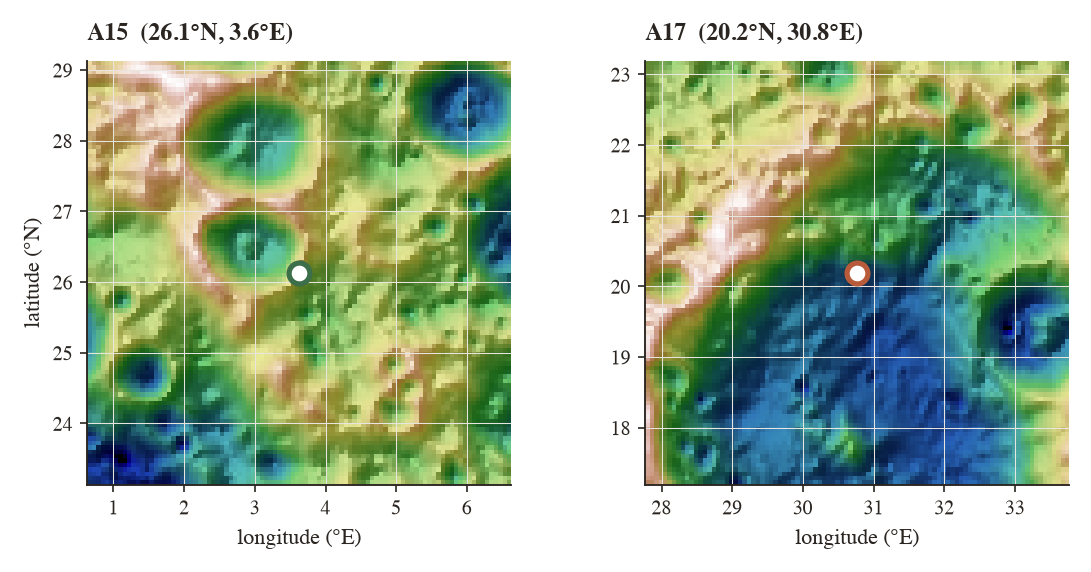

In [2]:
from matplotlib.colors import LightSource
import numpy as np, pathlib
p16 = ROOT/"data"/"lola"/"ldem_16.img"
ppd = 16 if p16.exists() else 4
demfile = p16 if p16.exists() else ROOT/"data"/"lola"/"ldem_4.img"
n_lat = 180*ppd
dem = np.fromfile(demfile, dtype="<i2").reshape(n_lat, 2*n_lat)*0.5/1000.0

def window(lat0, lon0, half=3.0):
    r0 = int((90-lat0-half)*ppd); r1 = int((90-lat0+half)*ppd)
    c0 = int((lon0+180-half)*ppd); c1 = int((lon0+180+half)*ppd)
    return dem[r0:r1, c0:c1], (lon0-half, lon0+half, lat0-half, lat0+half)

fig, axes = plt.subplots(1, 2, figsize=(JGR_FULL, 3.6), constrained_layout=True)
ls = LightSource(azdeg=315, altdeg=35)
for ax, sk in zip(axes, ("A15","A17")):
    s = sites[sk]
    w, ext = window(s["lat"], s["lon"])
    shaded = ls.shade(w, cmap=plt.get_cmap("gist_earth"), blend_mode="soft",
                      vert_exag=40)
    ax.imshow(shaded, extent=ext, origin="upper")
    ax.plot(s["lon"], s["lat"], "o", color="white", ms=10, mec=SITE_COLOR[sk], mew=2.5)
    fmt_axis(ax, xlabel="longitude (°E)", ylabel="latitude (°N)" if sk=="A15" else "",
             title=f"{sk}  ({s['lat']:.1f}°N, {s['lon']:.1f}°E)")
fig.canvas.draw()
plt.show()

## 2. Terrain horizons and the shadowed forcing
For each site the DEM is ray-marched in azimuth to the horizon elevation
angle (including the spherical curvature drop). The Sun is blocked
whenever its elevation is below the horizon at its current azimuth —
that zeroes samples of the standard forcing near sunrise/sunset.

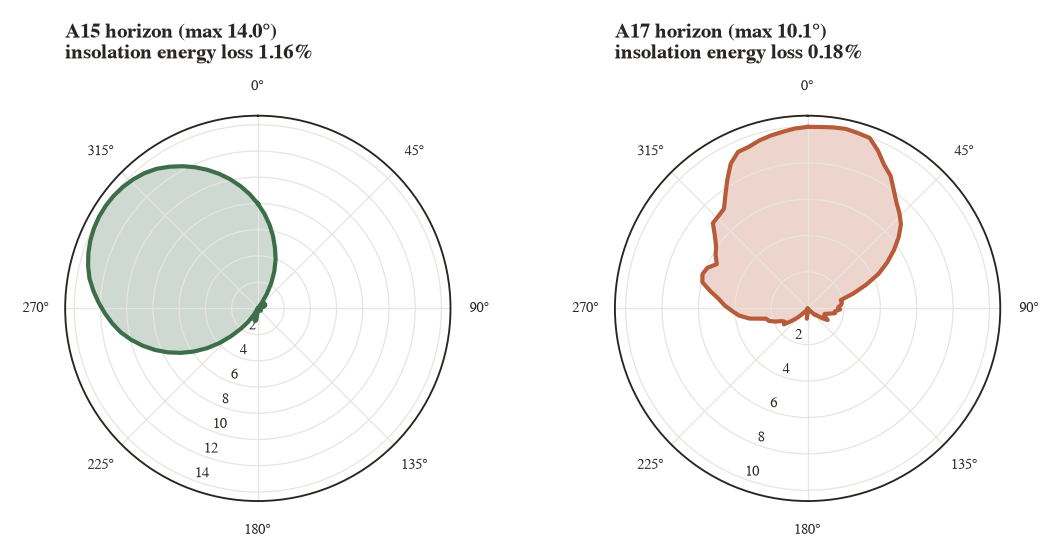

In [3]:
fig = plt.figure(figsize=(JGR_FULL, 3.6))
axp = [fig.add_subplot(1, 2, i+1, projection="polar") for i in range(2)]
for ax, sk in zip(axp, ("A15","A17")):
    s = sites[sk]
    az = np.radians(np.asarray(s["horizon_az_deg"]))
    hor = np.asarray(s["horizon_deg"])
    ax.plot(np.append(az, az[0]), np.append(hor, hor[0]), color=SITE_COLOR[sk], lw=2)
    ax.fill(np.append(az, az[0]), np.append(hor, hor[0]), color=SITE_COLOR[sk], alpha=0.25)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_title(f"{sk} horizon (max {s['horizon_max_deg']:.1f}°)\n"
                 f"insolation energy loss {100*s['insolation_energy_loss']:.2f}%",
                 fontsize=10)
    ax.set_rlabel_position(200); ax.tick_params(labelsize=7)
fig.tight_layout(); plt.show()

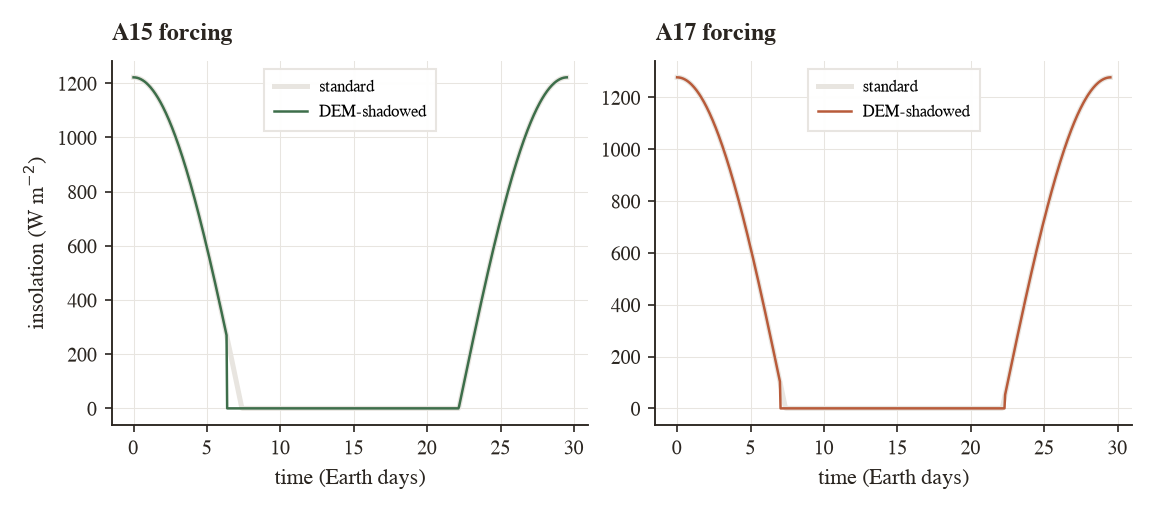

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(JGR_FULL, 3.2), constrained_layout=True)
for ax, sk in zip(axes, ("A15","A17")):
    fs = d["forcing_samples"][sk]
    ax.plot(fs["t_days"], fs["S_standard"], color=C_GRID, lw=2.4, label="standard")
    ax.plot(fs["t_days"], fs["S_shadowed"], color=SITE_COLOR[sk], lw=1.2,
            label="DEM-shadowed")
    fmt_axis(ax, xlabel="time (Earth days)", ylabel="insolation (W m$^{-2}$)" if sk=="A15" else "",
             title=f"{sk} forcing")
    ax.legend(frameon=True, edgecolor=C_GRID, fontsize=8)
    fig.canvas.draw(); assert_no_overlap(ax)
plt.show()

## 3. The constructed density profiles
The continuous Hayne ρ(z) (dashed) against the 3-layer discretizations.
Each gray staircase is one swept candidate; the best per site (by
deep-sensor RMSE under the shadowed forcing) is highlighted.

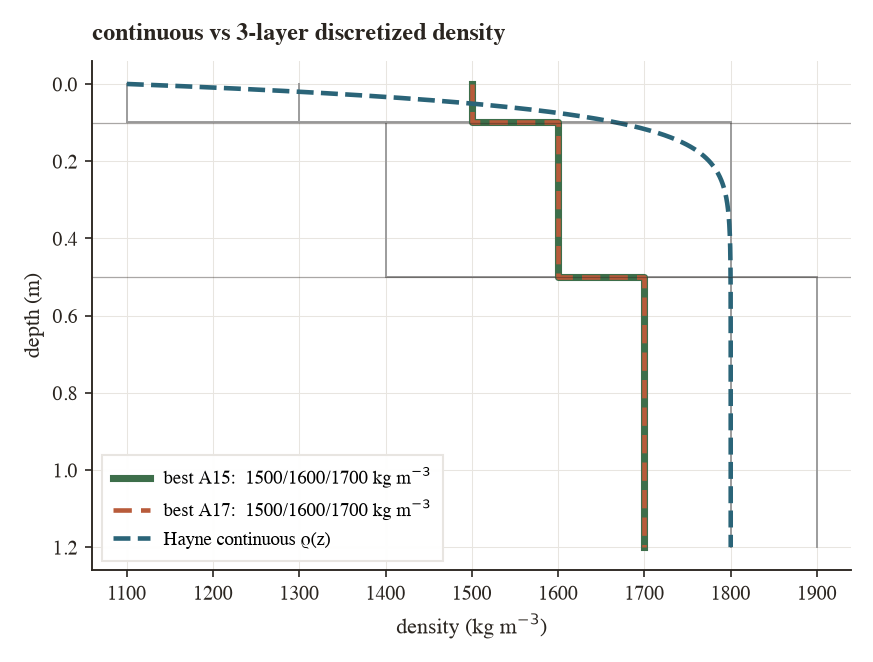

In [5]:
from lunar.properties import density_hayne
z = np.linspace(0, 1.2, 400)
Z1, Z2 = meta["z1_m"], meta["z2_m"]
def rho3(z, c):
    return np.where(z < Z1, c[0], np.where(z < Z2, c[1], c[2]))
best = {s: d["certification"][s]["best_profile"] for s in ("A15","A17")}
combos = sorted({r["profile"] for r in runs if r["profile"] != "hayne-continuous"})

fig, ax = plt.subplots(figsize=(JGR_FULL*0.75, 4.2), constrained_layout=True)
for pid in combos:
    c = [float(v) for v in pid.split("/")]
    ax.step(rho3(z, c), z, where="post", color="0.62", lw=0.8, alpha=0.8)
for sk, ls_, lw_ in (("A15", "-", 3.4), ("A17", (0, (4, 2)), 2.2)):
    c = [float(v) for v in best[sk].split("/")]
    ax.step(rho3(z, c), z, where="post", color=SITE_COLOR[sk], lw=lw_,
            linestyle=ls_, label=f"best {sk}:  {best[sk]} kg m$^{{-3}}$")
ax.plot(density_hayne(z), z, "--", color=C_HAYNE, lw=2.2, label="Hayne continuous ρ(z)")
ax.invert_yaxis()
for zz in (Z1, Z2):
    ax.axhline(zz, color=C_CHAR, lw=0.6, alpha=0.4)
fmt_axis(ax, xlabel="density (kg m$^{-3}$)", ylabel="depth (m)",
         title="continuous vs 3-layer discretized density")
ax.legend(frameon=True, edgecolor=C_GRID, fontsize=9, loc="lower left")
fig.canvas.draw(); assert_no_overlap(ax)
plt.show()

## 4. The sensitivity analysis
RMSE against the stable-window deep sensors for every 3-layer combination
(shadowed forcing), beside the continuous-Hayne baseline. The heatmaps
slice the (ρ₁, ρ₂) plane at each deep-layer density ρ₃.

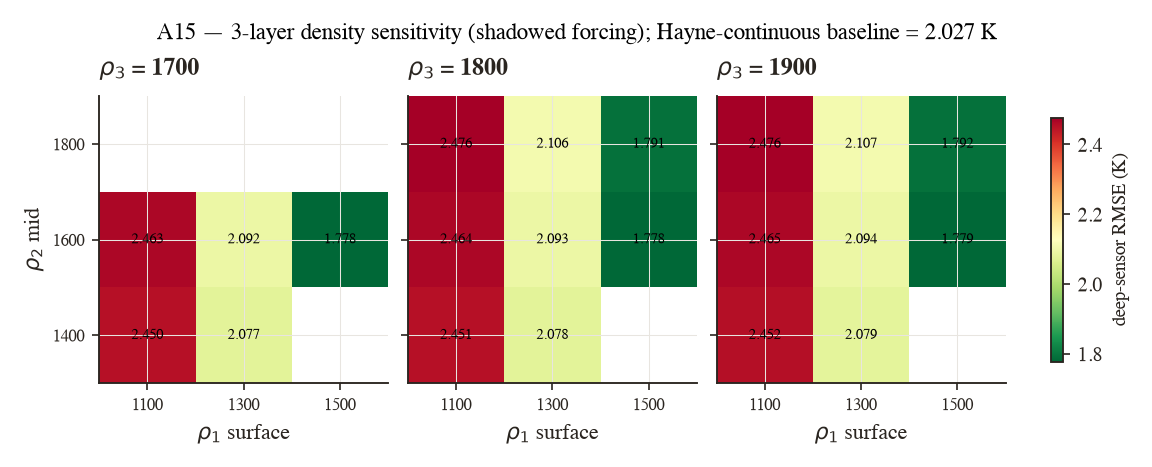

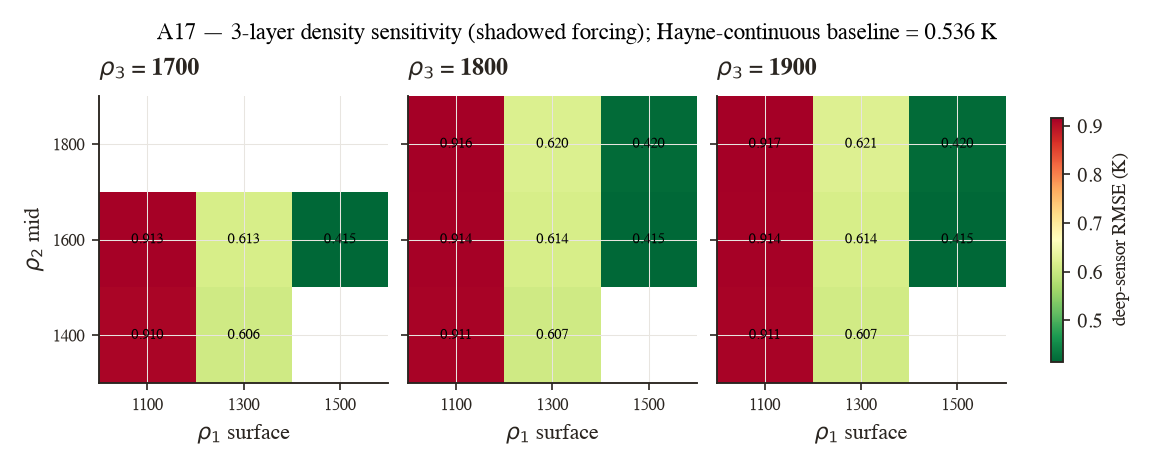

In [6]:
import matplotlib as mpl
for sk in ("A15","A17"):
    R = {tuple(r["rho"]): r["rmse_K"] for r in runs
         if r["site"]==sk and r["forcing"]=="shadowed" and r["profile"]!="hayne-continuous"}
    base = next(r["rmse_K"] for r in runs
                if r["site"]==sk and r["forcing"]=="shadowed" and r["profile"]=="hayne-continuous")
    l1, l2, l3 = meta["rho_l1"], meta["rho_l2"], meta["rho_l3"]
    fig, axes = plt.subplots(1, len(l3), figsize=(JGR_FULL, 2.9),
                             constrained_layout=True, sharey=True)
    vals = [v for v in R.values()]
    norm = mpl.colors.Normalize(min(vals), max(vals))
    for ax, r3 in zip(axes, l3):
        M = np.full((len(l2), len(l1)), np.nan)
        for i, r2 in enumerate(l2):
            for j, r1 in enumerate(l1):
                M[i, j] = R.get((r1, r2, r3), np.nan)
        im = ax.imshow(M, origin="lower", cmap="RdYlGn_r", norm=norm, aspect="auto")
        ax.set_xticks(range(len(l1)), [int(v) for v in l1], fontsize=8)
        ax.set_yticks(range(len(l2)), [int(v) for v in l2], fontsize=8)
        fmt_axis(ax, xlabel=r"$\rho_1$ surface", ylabel=r"$\rho_2$ mid" if r3==l3[0] else "",
                 title=rf"$\rho_3$ = {int(r3)}")
        for i in range(len(l2)):
            for j in range(len(l1)):
                if not np.isnan(M[i,j]):
                    ax.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center", fontsize=7,
                            color="black")
    cb = fig.colorbar(im, ax=axes, shrink=0.85)
    cb.set_label("deep-sensor RMSE (K)", fontsize=9)
    fig.suptitle(f"{sk} — 3-layer density sensitivity (shadowed forcing); "
                 f"Hayne-continuous baseline = {base:.3f} K", fontsize=11)
    plt.show()

In [7]:
# shadowing leverage: standard vs shadowed RMSE for the SAME density profile
print(f"{'site':4s}  {'profile':18s}  {'RMSE std (K)':>12s}  {'RMSE shadowed':>13s}  {'Δ (mK)':>7s}")
for sk in ("A15","A17"):
    for pid in ["hayne-continuous", d["certification"][sk]["best_profile"]]:
        rs = {r["forcing"]: r["rmse_K"] for r in runs if r["site"]==sk and r["profile"]==pid}
        print(f"{sk:4s}  {pid:18s}  {rs['standard']:12.4f}  {rs['shadowed']:13.4f}"
              f"  {1000*(rs['shadowed']-rs['standard']):7.1f}")

site  profile             RMSE std (K)  RMSE shadowed   Δ (mK)
A15   hayne-continuous          0.9876         2.0275   1039.9
A15   1500/1600/1700            1.1143         1.7776    663.3
A17   hayne-continuous          0.3929         0.5363    143.5
A17   1500/1600/1700            0.4859         0.4149    -71.0


In [8]:
# ranked table: top 5 profiles per site (shadowed)
for sk in ("A15","A17"):
    rows = sorted((r for r in runs if r["site"]==sk and r["forcing"]=="shadowed"),
                  key=lambda r: r["rmse_K"])
    print(f"\n{sk}  (all converged: {all(r['converged'] for r in rows)})")
    for r in rows[:5]:
        print(f"   {r['profile']:18s}  RMSE {r['rmse_K']:.4f} K   "
              f"closure {100*r['flux_closure']:.2f}%")


A15  (all converged: True)
   1500/1600/1700      RMSE 1.7776 K   closure 0.68%
   1500/1600/1800      RMSE 1.7785 K   closure 0.72%
   1500/1600/1900      RMSE 1.7793 K   closure 0.76%
   1500/1800/1800      RMSE 1.7914 K   closure 0.72%
   1500/1800/1900      RMSE 1.7921 K   closure 0.76%

A17  (all converged: True)
   1500/1600/1700      RMSE 0.4149 K   closure 0.51%
   1500/1600/1800      RMSE 0.4152 K   closure 0.55%
   1500/1600/1900      RMSE 0.4155 K   closure 0.59%
   1500/1800/1800      RMSE 0.4199 K   closure 0.58%
   1500/1800/1900      RMSE 0.4201 K   closure 0.61%


## 5. Thermal-profile analysis: which discrete layering fits the boreholes?
The physical answer, not just an RMSE table: the modeled mean thermal
profile $\langle T\rangle(z)$ for **every** 3-layer density candidate
(shadowed forcing), colored by the surface-layer density $\rho_1$ — the
layer the heatmaps showed carries all the leverage. Black points are the
stable-window sensor temperatures with their scatter. The top row shows
the full column; the bottom row zooms to the deep sensors that score the
fit. The best candidate (thick line) is the one whose profile threads
the sensor points.

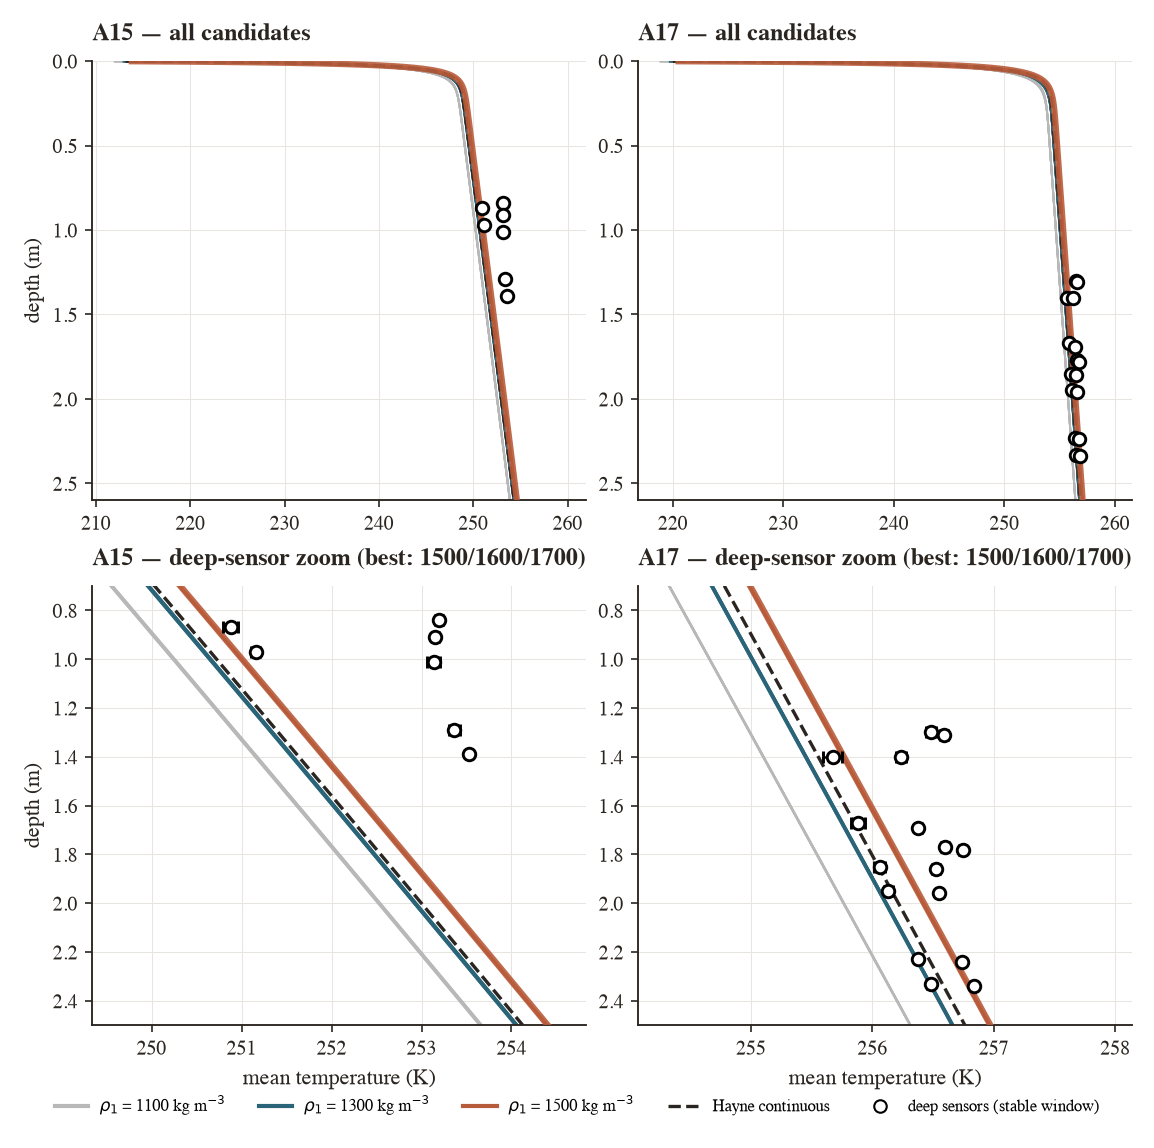

A15: best 1500/1600/1700 vs worst 1100/1800/1900 -> deep-sensor temperatures differ by 0.77-0.78 K
A17: best 1500/1600/1700 vs worst 1100/1800/1900 -> deep-sensor temperatures differ by 0.66-0.67 K


In [9]:
z_grid = np.asarray(meta["z_mid_m"])
RHO1_COLOR = {1100.0: "0.72", 1300.0: C_TEAL, 1500.0: C_A17}
fig, axes = plt.subplots(2, 2, figsize=(JGR_FULL, 7.2), constrained_layout=True)
for col, sk in enumerate(("A15", "A17")):
    s = sites[sk]
    cand = [r for r in runs if r["site"] == sk and r["forcing"] == "shadowed"
            and r["profile"] != "hayne-continuous"]
    hayne = next(r for r in runs if r["site"] == sk and r["forcing"] == "shadowed"
                 and r["profile"] == "hayne-continuous")
    bestp = d["certification"][sk]["best_profile"]
    zs = np.asarray(s["sensor_depth_cm"]) / 100.0
    Ts = np.asarray(s["sensor_T_eq"])
    Te = np.asarray(s["sensor_T_std"])
    for row, (z_lo, z_hi) in enumerate([(0.0, 2.6), (0.7, 2.5)]):
        ax = axes[row, col]
        for r in cand:
            c = RHO1_COLOR[float(r["rho"][0])]
            lw, zo = (0.9, 2) if r["profile"] != bestp else (3.0, 4)
            ax.plot(r["T_mean_profile"], z_grid, color=c, lw=lw, alpha=0.9,
                    zorder=zo)
        ax.plot(hayne["T_mean_profile"], z_grid, "--", color=C_CHAR, lw=1.6,
                zorder=3)
        ax.errorbar(Ts, zs, xerr=Te, fmt="o", color="black", ms=6,
                    mfc="white", mew=1.4, elinewidth=1.2, capsize=3, zorder=6)
        ax.set_ylim(z_hi, z_lo)
        if row == 1:
            m = (z_grid >= z_lo) & (z_grid <= z_hi)
            tt = np.concatenate([np.asarray(r["T_mean_profile"])[m] for r in cand])
            ax.set_xlim(min(tt.min(), Ts.min() - 1) - 0.3,
                        max(tt.max(), Ts.max() + 1) + 0.3)
        fmt_axis(ax, xlabel="mean temperature (K)" if row == 1 else "",
                 ylabel="depth (m)" if col == 0 else "",
                 title=(f"{sk} — all candidates" if row == 0
                        else f"{sk} — deep-sensor zoom (best: {bestp})"))
from matplotlib.lines import Line2D
handles = ([Line2D([0], [0], color=RHO1_COLOR[v], lw=2,
                   label=rf"$\rho_1$ = {int(v)} kg m$^{{-3}}$")
            for v in (1100.0, 1300.0, 1500.0)]
           + [Line2D([0], [0], color=C_CHAR, ls="--", lw=1.6,
                     label="Hayne continuous"),
              Line2D([0], [0], marker="o", color="black", mfc="white", lw=0,
                     label="deep sensors (stable window)")])
fig.legend(handles=handles, loc="lower center", ncols=5, frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, -0.035))
for ax in axes.ravel():
    fig.canvas.draw(); assert_no_overlap(ax)
plt.show()

# what separates the best from the worst, in kelvin at the sensors
for sk in ("A15", "A17"):
    cand = [r for r in runs if r["site"] == sk and r["forcing"] == "shadowed"
            and r["profile"] != "hayne-continuous"]
    best = min(cand, key=lambda r: r["rmse_K"])
    worst = max(cand, key=lambda r: r["rmse_K"])
    dT = np.asarray(best["T_model_at_sensors"]) - np.asarray(worst["T_model_at_sensors"])
    print(f"{sk}: best {best['profile']} vs worst {worst['profile']} -> "
          f"deep-sensor temperatures differ by {abs(dT).min():.2f}-{abs(dT).max():.2f} K")

## 6. Reading the first-pass result
The cells above print everything quantitative; the pattern to present at
AOGS:

- **Topography → horizons → forcing:** the DEM gives each site a real
  horizon; the Sun spends the first/last part of each lunar day behind
  it, deleting a small slice of the insolation energy.
- **Density discretization:** the RMSE spread across all 3-layer
  combinations quantifies exactly how much (or little) the deep
  stable-window temperatures care about the heat-capacity profile at
  fixed K — the per-layer heatmaps show which layer carries whatever
  leverage exists.
- **Certification:** the best combo re-run at the production inner
  spin-up (n=96) agrees to the printed mK drift, so the ranking is not a
  convergence artifact.

To change the discretization (layer boundaries or density grids), edit
the constants at the top of `code/pipeline/compute/aogs/s1_sensitivity.py`,
delete `results/aogs_sensitivity.json`, and re-run the script.

# Part II — the extensive density study: swept boundaries × two physics branches

**The question.** Part I fixed the 3-layer boundaries at 10/50 cm and
held conductivity at the certified per-site K_d\*; it found the surface
layer's density is the only heat-capacity lever. This study sweeps the
**configuration space**:

- **Layer boundaries:** z₁ ∈ {5, 10, 20} cm × z₂ ∈ {30, 50, 80} cm
- **Layer densities:** ρ₁ ≤ ρ₂ ≤ ρ₃ over 18 ordered combinations
- **Two physics branches:**
  - **cp** — densities set the heat capacity ρ·c_p only (K fixed at K_d\*)
  - **coupled** — densities *also* set the contact conductivity through
    the Hayne model's own internal relation. The model writes K_c(z) and
    ρ(z) with the same e^(−z/H) kernel; eliminating the kernel gives the
    exact linear map
    **K_c(ρ) = K_d\* − (K_d\* − K_s)·(ρ_d − ρ)/(ρ_d − ρ_s)** —
    no new constants introduced.
- **Forcing:** DEM-shadowed (notebook 08's horizons).

162 configurations per site per branch, ~650 certified equilibrium solves
(`code/pipeline/compute/aogs/s2_density_study.py` →
`results/aogs_density_study.json`); this notebook only reads and draws.

In [10]:
# NOTE: from here on, d/meta/sites/runs are RE-BOUND to the
# density-study archive (Part I bound them to aogs_sensitivity.json).
import json, numpy as np, matplotlib.pyplot as plt
from lunar._bootstrap import find_repo_root
from lunar.plotting.style import (JGR_FULL, C_A15, C_A17, C_HAYNE, C_CHAR,
                                  C_GRID, C_TEAL, fmt_axis, assert_no_overlap)
ROOT = find_repo_root()
d = json.loads((ROOT/"results"/"aogs_density_study.json").read_text())
meta, sites, runs = d["meta"], d["sites"], d["runs"]
SITE_COLOR = {"A15": C_A15, "A17": C_A17}
BR_NAME = {"cp": "heat-capacity only", "coupled": "density-coupled K"}
print("runs:", len(runs))
print("certification (best config, n_inner 24 vs 96):")
for k, c in d["certification"].items():
    print(f"  {k:12s} z1={c['z1_m']:.2f} z2={c['z2_m']:.2f} rho={c['rho']}  "
          f"RMSE {c['rmse_sweep']:.3f} -> {c['rmse_n96']:.3f} K "
          f"(drift {1000*c['drift_K']:.1f} mK)")

runs: 650
certification (best config, n_inner 24 vs 96):
  A15/cp       z1=0.05 z2=0.30 rho=[1500.0, 1700.0, 1700.0]  RMSE 1.744 -> 1.709 K (drift 35.1 mK)
  A15/coupled  z1=0.10 z2=0.30 rho=[1500.0, 1700.0, 1800.0]  RMSE 0.904 -> 0.908 K (drift 4.0 mK)
  A17/cp       z1=0.05 z2=0.30 rho=[1500.0, 1700.0, 1700.0]  RMSE 0.395 -> 0.390 K (drift 4.7 mK)
  A17/coupled  z1=0.05 z2=0.30 rho=[1300.0, 1500.0, 1900.0]  RMSE 0.362 -> 0.358 K (drift 4.6 mK)


## 7. Where should the layer boundaries be?
For each (z₁, z₂) boundary pair: the best RMSE over all 18 density
combinations. If the surface is the only lever, the **cp** maps should be
flat; any structure in the **coupled** maps is conductivity talking.

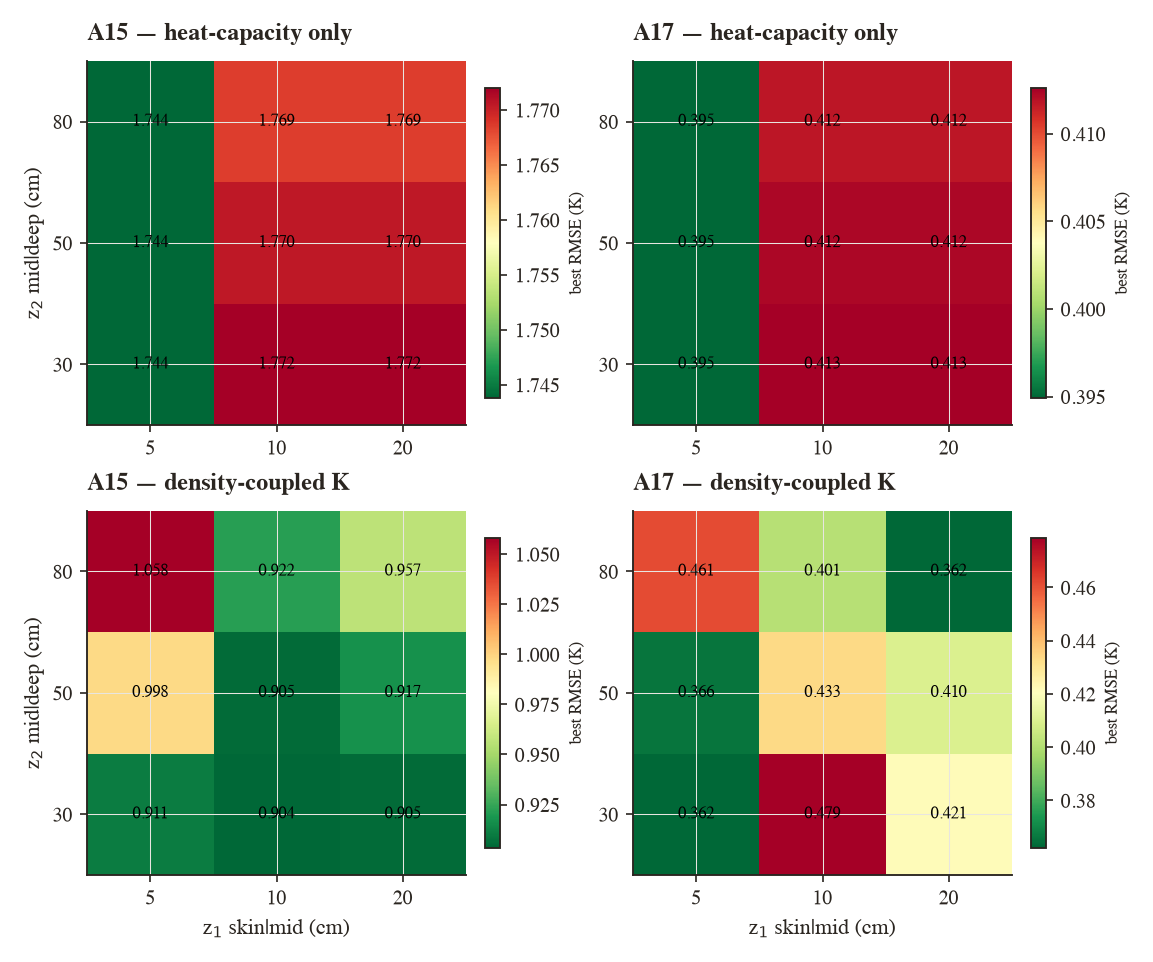

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(JGR_FULL, 6.2), constrained_layout=True)
z1g, z2g = meta["z1_grid"], meta["z2_grid"]
for i, br in enumerate(("cp", "coupled")):
    for j, sk in enumerate(("A15", "A17")):
        M = np.full((len(z2g), len(z1g)), np.nan)
        for a, z2 in enumerate(z2g):
            for b, z1 in enumerate(z1g):
                cand = [r["rmse_K"] for r in runs
                        if r["site"]==sk and r["branch"]==br
                        and r["rho"]!="hayne"
                        and abs(r["z1_m"]-z1)<1e-9 and abs(r["z2_m"]-z2)<1e-9]
                M[a, b] = min(cand)
        ax = axes[i, j]
        im = ax.imshow(M, origin="lower", cmap="RdYlGn_r", aspect="auto")
        ax.set_xticks(range(len(z1g)), [f"{100*v:.0f}" for v in z1g])
        ax.set_yticks(range(len(z2g)), [f"{100*v:.0f}" for v in z2g])
        for a in range(len(z2g)):
            for b in range(len(z1g)):
                ax.text(b, a, f"{M[a,b]:.3f}", ha="center", va="center",
                        fontsize=8)
        fmt_axis(ax, xlabel="z$_1$ skin|mid (cm)" if i==1 else "",
                 ylabel="z$_2$ mid|deep (cm)" if j==0 else "",
                 title=f"{sk} — {BR_NAME[br]}")
        fig.colorbar(im, ax=ax, shrink=0.85).set_label("best RMSE (K)", fontsize=8)
plt.show()

## 8. How much does each ingredient matter?
The RMSE spread across all 162 configurations, per site and branch —
the size of each box is the leverage the density discretization has.

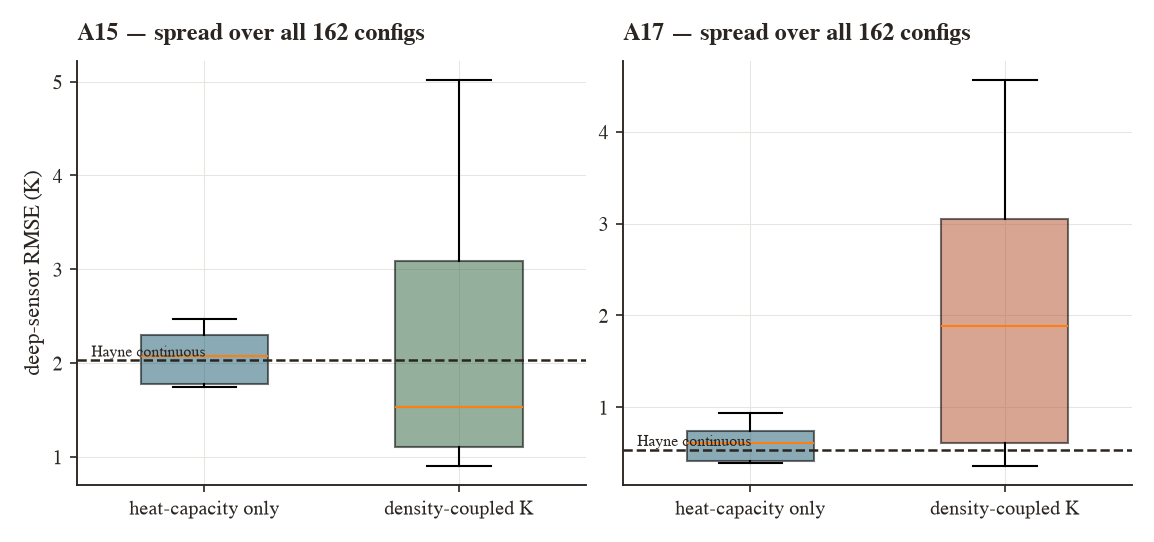

A15/cp      : RMSE 1.744 .. 2.472 K (spread 0.728)
A15/coupled : RMSE 0.904 .. 5.018 K (spread 4.114)
A17/cp      : RMSE 0.395 .. 0.933 K (spread 0.538)
A17/coupled : RMSE 0.362 .. 4.562 K (spread 4.200)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(JGR_FULL, 3.4), constrained_layout=True)
for ax, sk in zip(axes, ("A15", "A17")):
    data, labels, colors = [], [], []
    for br in ("cp", "coupled"):
        vals = [r["rmse_K"] for r in runs if r["site"]==sk
                and r["branch"]==br and r["rho"]!="hayne"]
        data.append(vals); labels.append(BR_NAME[br])
        colors.append(C_TEAL if br=="cp" else SITE_COLOR[sk])
    base = next(r["rmse_K"] for r in runs if r["site"]==sk and r["rho"]=="hayne")
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.5)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.55)
    ax.axhline(base, color=C_CHAR, ls="--", lw=1.2)
    ax.text(0.02, base, " Hayne continuous", fontsize=7.5, color=C_CHAR,
            va="bottom", transform=ax.get_yaxis_transform())
    fmt_axis(ax, ylabel="deep-sensor RMSE (K)" if sk=="A15" else "",
             title=f"{sk} — spread over all 162 configs")
plt.show()
for sk in ("A15","A17"):
    for br in ("cp","coupled"):
        vals = [r["rmse_K"] for r in runs if r["site"]==sk and r["branch"]==br
                and r["rho"]!="hayne"]
        print(f"{sk}/{br:8s}: RMSE {min(vals):.3f} .. {max(vals):.3f} K "
              f"(spread {max(vals)-min(vals):.3f})")

## 9. Thermal profiles of the winning configurations
The best configuration per branch against the sensors (deep zoom).
The coupled branch can *tilt* the deep gradient (K changes), which the
cp branch cannot — watch the slopes.

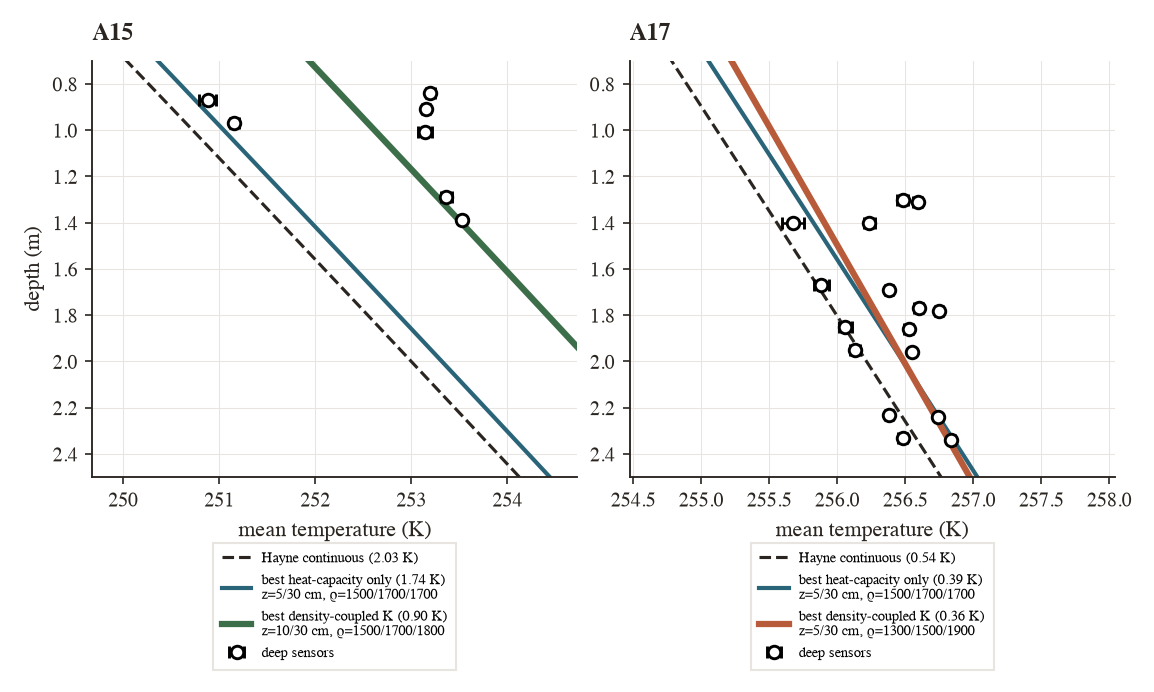

In [13]:
z_grid = np.asarray(meta["z_mid_m"])
fig, axes = plt.subplots(1, 2, figsize=(JGR_FULL, 4.4), constrained_layout=True)
for ax, sk in zip(axes, ("A15", "A17")):
    s = sites[sk]
    zs = np.asarray(s["sensor_depth_cm"])/100.0
    Ts = np.asarray(s["sensor_T_eq"]); Te = np.asarray(s["sensor_T_std"])
    zm = z_grid <= 2.7          # only the displayed window: clipped
    zg = z_grid[zm]             # tails would trip the overlap guard
    hay = next(r for r in runs if r["site"]==sk and r["rho"]=="hayne")
    ax.plot(np.asarray(hay["T_mean_profile"])[zm], zg, "--", color=C_CHAR, lw=1.5,
            label=f"Hayne continuous ({hay['rmse_K']:.2f} K)")
    for br, ls_, lw_ in (("cp", "-", 2.0), ("coupled", "-", 3.0)):
        best = min((r for r in runs if r["site"]==sk and r["branch"]==br
                    and r["rho"]!="hayne"), key=lambda r: r["rmse_K"])
        col = C_TEAL if br=="cp" else SITE_COLOR[sk]
        ax.plot(np.asarray(best["T_mean_profile"])[zm], zg, ls_, color=col, lw=lw_,
                label=(f"best {BR_NAME[br]} ({best['rmse_K']:.2f} K)\n"
                       f"z={100*best['z1_m']:.0f}/{100*best['z2_m']:.0f} cm, "
                       f"ρ={'/'.join(str(int(v)) for v in best['rho'])}"))
    ax.errorbar(Ts, zs, xerr=Te, fmt="o", color="black", ms=6, mfc="white",
                mew=1.4, elinewidth=1.2, capsize=3, zorder=6,
                label="deep sensors")
    ax.set_ylim(2.5, 0.7)
    tt = np.concatenate([Ts-1.2, Ts+1.2])
    ax.set_xlim(tt.min(), tt.max())
    fmt_axis(ax, xlabel="mean temperature (K)",
             ylabel="depth (m)" if sk=="A15" else "", title=sk)
    ax.legend(fontsize=7, frameon=True, edgecolor=C_GRID,
              loc="upper center", bbox_to_anchor=(0.5, -0.14))
    fig.canvas.draw(); assert_no_overlap(ax)
plt.show()

## 10. Ranked results

In [14]:
for sk in ("A15","A17"):
    print(f"\n{sk} — top 5 per branch (shadowed forcing)")
    for br in ("cp","coupled"):
        rows = sorted((r for r in runs if r["site"]==sk and r["branch"]==br
                       and r["rho"]!="hayne"), key=lambda r: r["rmse_K"])
        print(f"  [{BR_NAME[br]}]")
        for r in rows[:5]:
            print(f"    z1={100*r['z1_m']:>3.0f} z2={100*r['z2_m']:>3.0f} cm  "
                  f"rho={'/'.join(str(int(v)) for v in r['rho']):>14s}  "
                  f"RMSE {r['rmse_K']:.4f} K")
    conv = all(r["converged"] for r in runs if r["site"]==sk)
    print(f"  all converged: {conv}")


A15 — top 5 per branch (shadowed forcing)
  [heat-capacity only]
    z1=  5 z2= 30 cm  rho=1500/1700/1700  RMSE 1.7438 K
    z1=  5 z2= 50 cm  rho=1500/1700/1700  RMSE 1.7438 K
    z1=  5 z2= 80 cm  rho=1500/1700/1700  RMSE 1.7438 K
    z1=  5 z2= 80 cm  rho=1500/1700/1800  RMSE 1.7438 K
    z1=  5 z2= 80 cm  rho=1500/1700/1900  RMSE 1.7438 K
  [density-coupled K]
    z1= 10 z2= 30 cm  rho=1500/1700/1800  RMSE 0.9035 K
    z1= 10 z2= 50 cm  rho=1500/1700/1900  RMSE 0.9047 K
    z1= 20 z2= 30 cm  rho=1500/1700/1900  RMSE 0.9050 K
    z1=  5 z2= 30 cm  rho=1500/1500/1900  RMSE 0.9106 K
    z1= 10 z2= 30 cm  rho=1500/1500/1900  RMSE 0.9106 K
  all converged: True

A17 — top 5 per branch (shadowed forcing)
  [heat-capacity only]
    z1=  5 z2= 30 cm  rho=1500/1700/1700  RMSE 0.3949 K
    z1=  5 z2= 50 cm  rho=1500/1700/1700  RMSE 0.3949 K
    z1=  5 z2= 80 cm  rho=1500/1700/1700  RMSE 0.3949 K
    z1=  5 z2= 80 cm  rho=1500/1700/1800  RMSE 0.3949 K
    z1=  5 z2= 80 cm  rho=1500/1700/1900

## 11. How robust are the winners? (10k-draw bootstrap, zero new solves)

`aogs_winner_bootstrap.py` resamples the seven deep sensors (with replacement,
plus their measured `T_std` as noise) against the **stored** model temperatures
of all 162 configs per branch — no solver calls — and asks two questions:
how often does the production winner stay the winner, and how tight is the
best-RMSE distribution?

**How to read it:** the *improvement over homogeneous* is bootstrap-solid
(the CIs below sit far under the 2.31 / 3.76 K homogeneous baselines), but the
*exact* A15 coupled triple is degenerate — quote the **class** of profile
(denser-than-Hayne surface, high transition), not one triple. At A17 the
densities 1300/1500/1900 are the stable part; only $z_2$ wobbles.

In [15]:
wb = json.loads((ROOT/"results"/"aogs_winner_bootstrap.json").read_text())
print(f"bootstrap: {wb['meta']['n_boot']} draws -- {wb['meta']['method']}\n")
for key in ("A15_cp", "A15_coupled", "A17_cp", "A17_coupled"):
    b = wb[key]
    lo, hi = b["best_rmse_ci95_K"]
    print(f"{key:12s} winner {b['production_winner']:28s} "
          f"stability {100*b['winner_stability']:5.1f}%   "
          f"best RMSE {b['best_rmse_median_K']:.2f} [{lo:.2f}, {hi:.2f}] K")
print("\nA17 coupled top-5 (the stable part is the density triple):")
for t in wb["A17_coupled"]["top5"]:
    print(f"  {t['config']:28s} {100*t['share']:5.1f}%")

bootstrap: 10000 draws -- sensor resample w/ replacement + N(0, T_std) noise; argmin over stored T_model_at_sensors

A15_cp       winner z=5/30 rho=1500/1700/1700    stability 100.0%   best RMSE 1.75 [1.18, 2.17] K
A15_coupled  winner z=10/30 rho=1500/1700/1800   stability  13.3%   best RMSE 0.85 [0.26, 1.08] K
A17_cp       winner z=5/30 rho=1500/1700/1700    stability  88.2%   best RMSE 0.39 [0.26, 0.52] K
A17_coupled  winner z=5/30 rho=1300/1500/1900    stability  35.8%   best RMSE 0.35 [0.25, 0.43] K

A17 coupled top-5 (the stable part is the density triple):
  z=5/50 rho=1300/1500/1900     37.0%
  z=5/30 rho=1300/1500/1900     35.8%
  z=20/80 rho=1300/1500/1900    14.9%
  z=5/30 rho=1300/1700/1900      6.3%
  z=5/50 rho=1300/1700/1900      2.1%


## 12. Could a single $K_d$ do the job under shadowed forcing?

Re-retrieving a **pure** $K_d$ (continuous Hayne density, only the forcing
shadowed) answers whether layers are actually needed. The grids were extended
to the physical bounds (`aogs_kd_shadowed_extend.py`), so both minima are now
**interior** — a pure-$K_d$ model *can* fit, but look at what it costs:

- **A15** wants $K_d = 1.88$ mW — far *outside* the letter's bootstrap CI
  [4.18, 6.96] — and still fits worse (1.10 K) than the coupled winner (0.90 K).
- **A17** wants 9.69 mW (letter: 7.08), i.e. shadowing distorts the pure-$K$
  optimum instead of breaking it.
- Hayne's **global** $K_d = 3.4$ mW is the named baseline: 1.90 / 0.71 K.

**Anchor hierarchy** (how to quote these): site $K_d^*$ = the anchor ·
global 3.4 = named baseline · shadowed vertices = *diagnostic only*, never
an anchor. The bowl figure (built by `make_explainer_kd_bowl.py`) shows all
three markers per site.

pure-K_d retrieval under DEM-shadowed forcing (grids at physical bounds):
  A15: letter K_d* 4.60 -> shadowed vertex 1.88 mW (shift -2.72; RMSE 1.10 K; interior: True)
  A17: letter K_d* 7.08 -> shadowed vertex 9.69 mW (shift +2.61; RMSE 0.32 K; interior: True)
global K_d = 3.4 mW baseline:  A15 1.90 K, A17 0.71 K


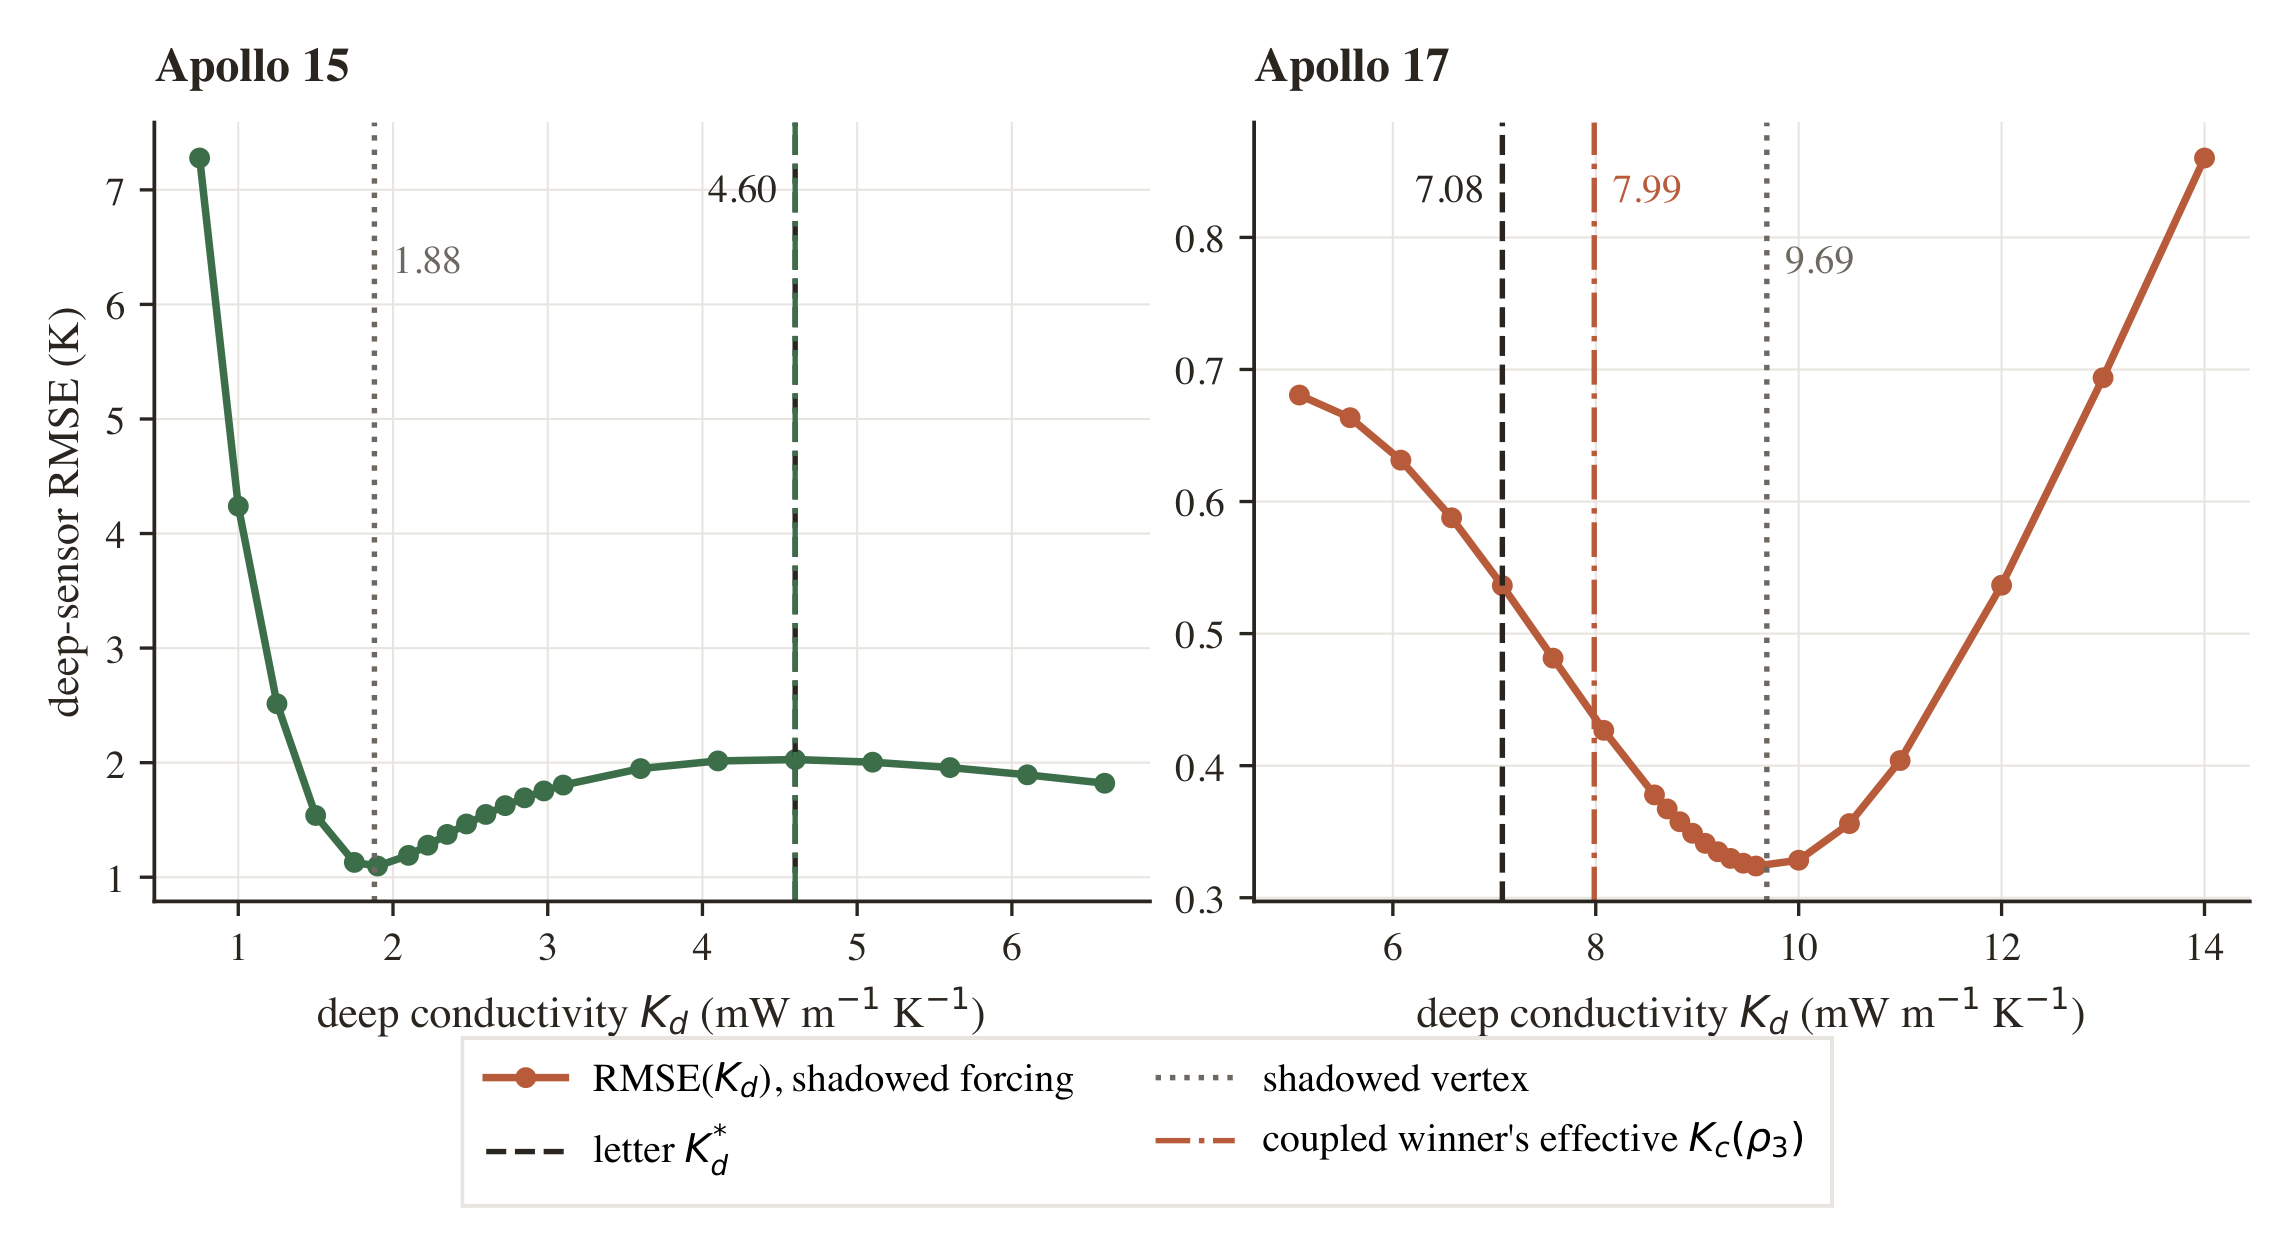

In [16]:
ks = json.loads((ROOT/"results"/"aogs_kd_shadowed.json").read_text())
gb = json.loads((ROOT/"results"/"aogs_global_kd_baseline.json").read_text())
print("pure-K_d retrieval under DEM-shadowed forcing (grids at physical bounds):")
for sk in ("A15", "A17"):
    s = ks["sites"][sk]
    print(f"  {sk}: letter K_d* {s['kd_star_standard_mW']:.2f} -> shadowed vertex "
          f"{s['kd_star_shadowed_mW']:.2f} mW (shift {s['shift_mW']:+.2f}; "
          f"RMSE {s['rmse_min_K']:.2f} K; interior: {s['min_interior']})")
print(f"global K_d = {gb['meta']['kd_mW']} mW baseline:  "
      f"A15 {gb['A15']['rmse_K']:.2f} K, A17 {gb['A17']['rmse_K']:.2f} K")

from IPython.display import Image, display
display(Image(filename=str(ROOT.parent/"deliverables"/"documents"/"aogs"/"talk_figures"
                           /"explainer_kd_bowl.png"), width=900))

## 13. The second topographic channel: $(1-\mathrm{SVF})$ terrain radiation

Terrain that blocks the Sun also *glows* (infrared) and *reflects* sunlight.
`aogs_svf_terms.py` quantifies both at the coupled winners with the
$T_\mathrm{terr} \approx T_s$ **upper bound** (6 solves, archived in the JSON):
the sky-view factor sets the emissivity through
$\varepsilon_\mathrm{eff} = \varepsilon\,(1-\varepsilon\,(1-\mathrm{SVF}))$
and the reflected term adds $(1-\mathrm{SVF})\,A\,S_\mathrm{unshadowed}$
to the forcing.

**The poster's "topography enters twice" box comes from here:** shadowing
removes ~1 K at depth, terrain radiation puts up to about the same back —
two opposing first-order channels whose *net* is small. Caveat: the winners
were tuned *without* these terms, so they fit worse with them switched on —
the identified next step is a full re-sweep with terrain terms enabled.

In [17]:
sv = json.loads((ROOT/"results"/"aogs_svf_terms.json").read_text())
print(f"model: {sv['meta']['model']}\n")
print(f"{'site':5s} {'SVF':>7s} {'IR only':>9s} {'IR+refl':>9s}   (mean dT at the deep sensors, K)")
for sk in ("A15", "A17"):
    s = sv[sk]
    print(f"{sk:5s} {s['svf']:7.4f} {s['dT_mean_ir_selfheat_K']:+9.2f} "
          f"{s['dT_mean_ir_plus_reflected_K']:+9.2f}")
loss = {"A15": 1.16, "A17": 0.18}  # % insolation deleted (aogs_sensitivity.json)
sens = json.loads((ROOT/"results"/"aogs_sensitivity.json").read_text())
for sk in ("A15", "A17"):
    assert abs(100*sens["sites"][sk]["insolation_energy_loss"] - loss[sk]) < 0.01
print("\nopposing channel: shadowing deletes 1.16% / 0.18% of insolation (~1 K at depth)")

model: eps_eff = eps*(1-eps*(1-SVF)) [T_terr ~= T_s]; reflected = (1-SVF)*albedo*S_unshadowed added to forcing

site      SVF   IR only   IR+refl   (mean dT at the deep sensors, K)
A15    0.9848     +1.15     +1.30
A17    0.9914     +0.65     +0.74

opposing channel: shadowing deletes 1.16% / 0.18% of insolation (~1 K at depth)


## 14. Geology check — and the $K_d \leftrightarrow \rho$ degeneracy

**Geology:** the retrieved deep densities (1800 / 1900 kg m$^{-3}$) match the
*measured* Apollo drive-core bulk densities — 1825 (A15) / 1960 (A17)
kg m$^{-3}$, Grott et al. (JGR Planets), as quoted in the Chandrayaan-3
comparison paper in `code/references/` — in **value and ordering**.

**Degeneracy (the central caveat):** the deep gradient is $\approx Q_b /
K_\mathrm{deep}$, so deep conductivity and deep density are *not separately
retrievable* from one gradient. In the coupled branch the winner's
**effective** deep conductivity is $K_c(\rho_3)$, not $K_d^*$: at A15,
$\rho_3 = 1800$ = Hayne's $\rho_d$, so it stays at 4.60; at A17,
$\rho_3 = 1900 > \rho_d$ pushes it to 7.99 (+0.91 above the letter).
The letter pinned $\rho$ and retrieved $K_d$; this study pins $K_d$ and
retrieves $\rho$ — **two conditional slices of one coupled 2-D space**.
Never quote "$K_d^* = 7.08$ *and* $\rho_3 = 1900$" as independent facts.

In [18]:
import sys
sys.path.insert(0, str(ROOT/"pipeline"/"compute"/"aogs"))
import s2_density_study as ds
kd = json.loads((ROOT/"results"/"kd_retrieval_results.json").read_text())
measured = {"A15": 1825, "A17": 1960}   # Grott et al., via chaste2025 (code/references/)
print(f"{'site':5s} {'K_d* (letter)':>14s} {'winner rho3':>12s} "
      f"{'effective K_c(rho3)':>20s} {'measured rho':>13s}")
for sk in ("A15", "A17"):
    win = min((r for r in runs if r["site"] == sk and r["branch"] == "coupled"
               and r["rho"] != "hayne"), key=lambda r: r["rmse_K"])
    rho3 = win["rho"][2]
    keff = 1e3 * float(ds.kc_of_rho(rho3, kd[sk]["kd_star"]))
    print(f"{sk:5s} {1e3*kd[sk]['kd_star']:14.2f} {rho3:12.0f} "
          f"{keff:20.2f} {measured[sk]:13d}")
print("\nA15: rho3 = Hayne rho_d -> effective K unchanged (the teaching point);")
print("A17: denser deep layer IS the letter's higher K_d*, in different clothes.")

site   K_d* (letter)  winner rho3  effective K_c(rho3)  measured rho
A15             4.60         1800                 4.60          1825
A17             7.08         1900                 7.99          1960

A15: rho3 = Hayne rho_d -> effective K unchanged (the teaching point);
A17: denser deep layer IS the letter's higher K_d*, in different clothes.


## 15. Take-aways (auto-check against the printed numbers)
- **Boundaries**: the boundary maps (§7) show whether moving the layer
  breaks matters per branch — flat cp maps mean the discretization depth
  is forgiving when only heat capacity is involved.
- **Branches**: the box plots (§8) compare the leverage of pure ρ·c_p
  against density-coupled conductivity; the coupled spread is the
  argument that *density knowledge matters through K, not through c_p*.
- **Profiles** (§9): the coupled winner can tilt the deep gradient toward
  the sensors — the physical mechanism the cp branch lacks.
- Certification drifts (Part II setup cell) confirm the rankings survive the
  production spin-up.
- **Robustness** (§11): the improvement is bootstrap-solid; the A15 coupled
  *triple* is degenerate (13%) — quote the class, not the triple.
- **Pure $K_d$** (§12): can fit, but at A15 only far outside the letter CI
  and still worse than layers — vertices are diagnostics, never anchors.
- **Two topographic channels** (§13): shadowing (−) and $(1-\mathrm{SVF})$
  terrain radiation (+) are the same order; both are on the poster.
- **Degeneracy** (§14): deep density and deep conductivity are one
  constraint, not two facts — the joint retrieval is the next paper.

To modify the study: edit the `EDIT HERE` grids in
`code/pipeline/compute/aogs/s2_density_study.py`, delete
`results/aogs_density_study.json`, re-run, then Run All here.

## 16. Poster figure kit (2026-07-12 audit refresh)

The audit of the AOGS layer fixed two poster claims and added provenance + figures:

- **Shadow cooling at the deep sensors is 2.22 K (A15) / 0.48 K (A17)** (standard vs
  shadowed forcing, Hayne-continuous, same `n_inner` — clean difference), NOT the
  "~1 K" the old poster said. Against the terrain-IR warming (+1.15/+0.65 K), the
  **warming channel wins at A17**.
- The "flux closure <= 0.8%" claim was wrong as stated: 180/650 runs exceed it (max 43%),
  ALL of them coupled-branch with the z2 step at/below the 0.55 m anchor. Verified to be a
  METRIC artifact (max-over-cells differencing at the K discontinuity): the worst run's deep
  gradient still equals Q_b/K_deep to 3 decimals. Correct wording: all 650 converged on the
  anchor criterion; the winners close the budget to <= 0.7% and re-run at n=96 within 35 mK.
- `results/aogs_crossite.json` (homogeneous baseline 2.31/3.76 K + transfers 1.73/1.64 K) had
  **no writer**; `pipeline/compute/aogs/s5_crossite.py` now reproduces all four to 1e-4 and pins
  the recipe: homogeneous = const K_c = K_d* (radiative term kept) + rho = 1800, shadowed
  forcing; cross-site = structure-only transplant with the TARGET site's K_d*.
- New figures: TikZ **model schematic** (aogs/talk_figures), **transfer matrix** (poster_transfer),
  **sun-path overlay** on the horizon polars; profiles legend de-duplicated, density legend
  moved inside, forcing legend collision fixed.


In [19]:
# rebuild the poster panel set + poster_numbers.tex from the archives (pure re-plots)
# (the TikZ schematic builds separately:
#   cd deliverables/documents/talk_figures && pdflatex aogs_model_schematic.tex)
%run ../pipeline/figures/make_poster_figures.py

  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_dem.pdf
  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_horizons.pdf


  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_forcing.pdf
  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_sites.pdf


  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_profiles.pdf
  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_leverage.pdf


  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_boundaries.pdf
  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_sens.pdf


  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_density.pdf
  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_transfer.pdf
  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/figures/poster_bootstrap.pdf
  -> /Users/rp3gregorio/Developer/Lunar-Clean/deliverables/documents/aogs/poster/poster_numbers.tex (38 macros)


In [20]:
# the corrected headline numbers, straight from the archives
import json, numpy as np
sens = json.loads((ROOT/"results"/"aogs_sensitivity.json").read_text())
x = json.loads((ROOT/"results"/"aogs_crossite.json").read_text())
for sk in ("A15", "A17"):
    pair = {r["forcing"]: np.array(r["T_model_at_sensors"]) for r in sens["runs"]
            if r["site"] == sk and r["profile"] == "hayne-continuous"}
    print(f"{sk}: shadow cooling at the deep sensors "
          f"{np.mean(pair['standard'] - pair['shadowed']):.2f} K")
print("cross-site (structure-only, target K_d*): "
      f"A15@A17 {x['A15_config_at_A17']:.2f} K, A17@A15 {x['A17_config_at_A15']:.2f} K; "
      f"homogeneous {x['A15_homogeneous']:.2f} / {x['A17_homogeneous']:.2f} K")

A15: shadow cooling at the deep sensors 2.22 K
A17: shadow cooling at the deep sensors 0.48 K
cross-site (structure-only, target K_d*): A15@A17 1.64 K, A17@A15 1.73 K; homogeneous 2.31 / 3.76 K


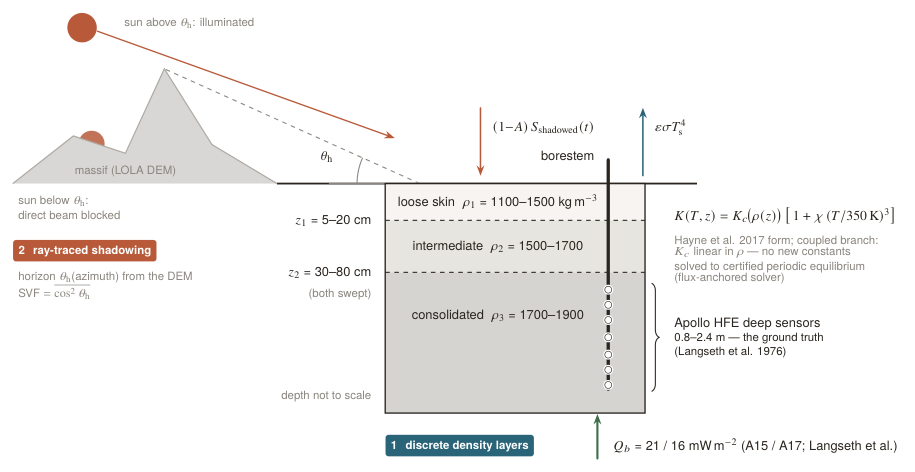

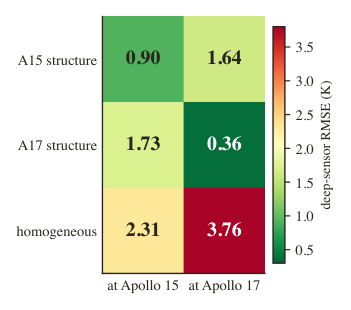

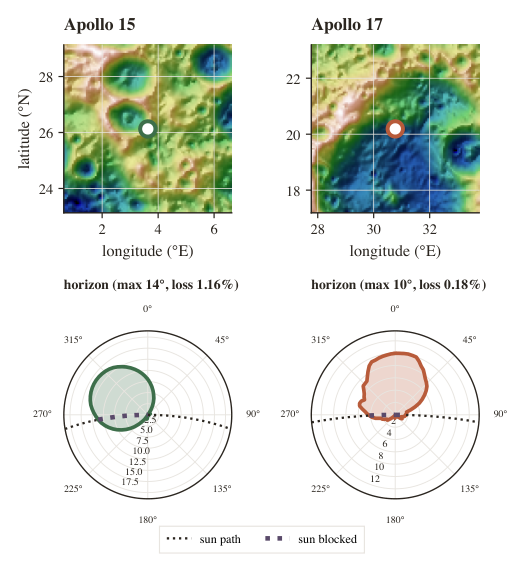

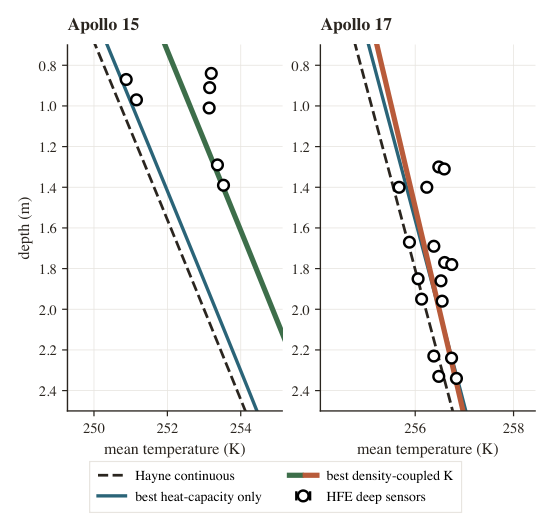

In [21]:
# view the new panels (schematic, transfer matrix, sun-path polars, shared-legend profiles)
from IPython.display import Image as IPImage, display
import fitz
POSTER = ROOT.parent / "deliverables" / "documents" / "aogs" / "poster" / "figures"
TALK = ROOT.parent / "deliverables" / "documents" / "aogs" / "talk_figures"
for pdf in [TALK / "aogs_model_schematic.pdf", POSTER / "poster_transfer.pdf",
            POSTER / "poster_sites.pdf", POSTER / "poster_profiles.pdf"]:
    pg = fitz.open(str(pdf))[0]
    display(IPImage(pg.get_pixmap(dpi=110).tobytes("png")))

## 17. The density sweep — what is fixed, what is searched

**We do NOT re-fit $K_d$ here.** Each borehole's deep conductivity is held at the
value our companion **letter** retrieved, $K_d^{*}=4.60$ (A15) $/\ 7.08$ (A17)
mW m$^{-1}$ K$^{-1}$. We then search only the **density structure** — 3 layers,
boundaries $z_1,z_2$ and densities $\rho_1\le\rho_2\le\rho_3$ (162 configs/site).

The two branches differ *only* in how density touches the conductivity:
- **cp** — density enters the heat capacity $\rho c_p$ only; $K$ stays at $K_d^{*}$.
- **coupled** — density *also* sets the contact conductivity along the Hayne
  form's own line $K_c(\rho)=K_d^{*}-(K_d^{*}-K_s)\,(\rho_d-\rho)/(\rho_d-\rho_s)$,
  **anchored** at $K_d^{*}$ (it equals $K_d^{*}$ at $\rho_d=1800$) and sliding as
  the swept $\rho_3$ moves.

Why fix $K_d$ and search density, instead of fitting both? Because they are
**degenerate**: the deep gradient $\approx Q_b/K_{\rm deep}$ constrains only the
*product*, so a higher $K_d$ and a denser deep layer look identical to the
sensors. (Anchoring at Hayne's *global* average $K_d=3.4$ instead would be
simpler but fits worse — best RMSE 1.90 / 0.71 K vs the per-site 0.90 / 0.36 K.)

The next figure makes this concrete; the one after shows the resulting sweep.

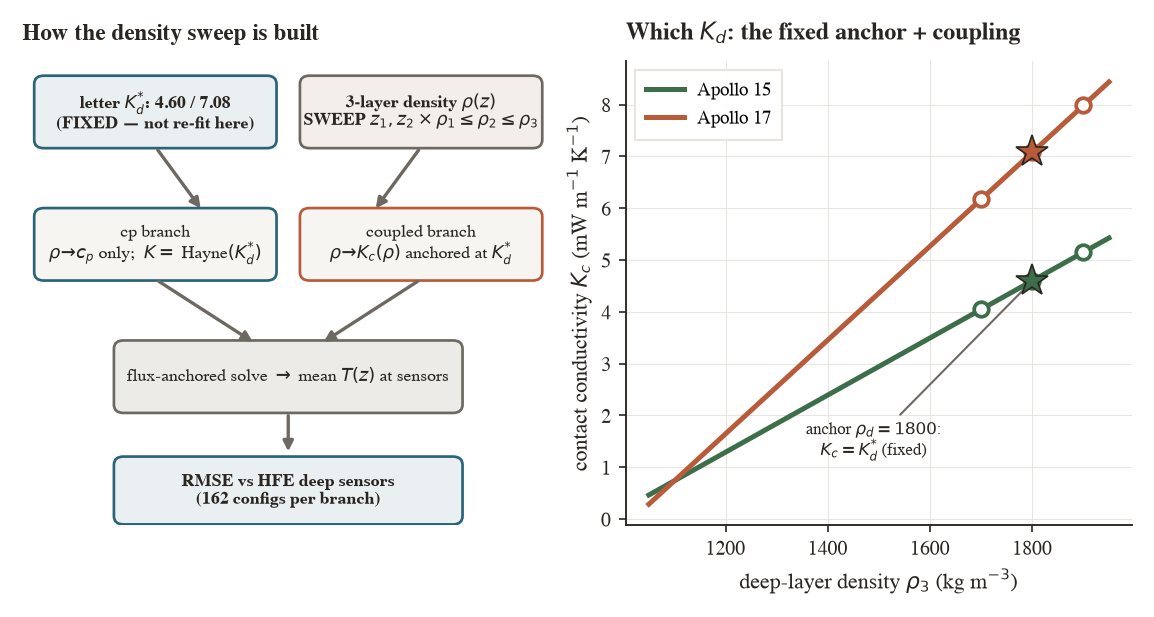

stars = the fixed K_d* anchor; open circles = the swept deep densities (1700/1800/1900)


In [22]:
# Method: what's FIXED (K_d*) vs SEARCHED (density), and the K_c(rho) coupling
import json, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from lunar.plotting.style import (JGR_FULL, C_A15, C_A17, C_CHAR, C_DIM, C_GRID,
                                  C_TEAL, fmt_axis, assert_no_overlap)
from lunar.constants import RHO_SURFACE, RHO_DEEP, K_SURFACE
_kd = json.loads((ROOT/"results"/"kd_retrieval_results.json").read_text())
KD = {"A15": _kd["A15"]["kd_star"]*1e3, "A17": _kd["A17"]["kd_star"]*1e3}
SITE = {"A15": C_A15, "A17": C_A17}; KS = K_SURFACE*1e3
fig, (axL, axR) = plt.subplots(1, 2, figsize=(JGR_FULL, 3.9),
                               gridspec_kw={"width_ratios": [1.05, 1]},
                               constrained_layout=True)
axL.set_xlim(0, 10); axL.set_ylim(0, 10); axL.axis("off")
def _box(x, y, w, h, t, fc, ec, bold=False):
    axL.add_patch(mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle="round,pad=0.08,rounding_size=0.18", fc=fc, ec=ec, lw=1.3))
    axL.text(x+w/2, y+h/2, t, ha="center", va="center", fontsize=8.5,
             color=C_CHAR, fontweight="bold" if bold else "normal")
def _arr(x0, y0, x1, y1):
    axL.annotate("", (x1, y1), (x0, y0),
                 arrowprops=dict(arrowstyle="-|>", color=C_DIM, lw=1.6))
_box(0.3,8.2,4.4,1.4,"letter $K_d^{*}$: 4.60 / 7.08\n(FIXED — not re-fit here)","#EAF0F2",C_TEAL,True)
_box(5.3,8.2,4.4,1.4,"3-layer density $\\rho(z)$\nSWEEP $z_1,z_2\\times\\rho_1{\\leq}\\rho_2{\\leq}\\rho_3$","#F3EEE9",C_DIM,True)
_arr(2.5,8.15,3.4,6.75); _arr(7.5,8.15,6.6,6.75)
_box(0.3,5.35,4.4,1.4,"cp branch\n$\\rho\\!\\to\\!c_p$ only;  $K=$ Hayne$(K_d^{*})$","#F7F5F1",C_TEAL)
_box(5.3,5.35,4.4,1.4,"coupled branch\n$\\rho\\!\\to\\!K_c(\\rho)$ anchored at $K_d^{*}$","#F7F5F1",C_A17)
_arr(2.5,5.3,4.4,3.9); _arr(7.5,5.3,5.6,3.9)
_box(1.8,2.5,6.4,1.4,"flux-anchored solve $\\to$ mean $T(z)$ at sensors","#EDEBE7",C_DIM)
_arr(5.0,2.45,5.0,1.5)
_box(1.8,0.1,6.4,1.3,"RMSE vs HFE deep sensors\n(162 configs per branch)","#EAF0F2",C_TEAL,True)
axL.set_title("How the density sweep is built", fontsize=11)
rho = np.linspace(1050, 1950, 200)
for sk in ("A15", "A17"):
    kc = KD[sk] - (KD[sk]-KS)*(RHO_DEEP-rho)/(RHO_DEEP-RHO_SURFACE)
    axR.plot(rho, kc, color=SITE[sk], lw=2.4, label=f"Apollo {sk[1:]}")
    axR.plot(RHO_DEEP, KD[sk], "*", color=SITE[sk], ms=16, mec=C_CHAR, mew=0.8, zorder=6)
    for r3 in (1700., 1800., 1900.):
        k3 = KD[sk]-(KD[sk]-KS)*(RHO_DEEP-r3)/(RHO_DEEP-RHO_SURFACE)
        axR.plot(r3, k3, "o", color="white", mec=SITE[sk], mew=1.8, ms=7, zorder=5)
axR.annotate("anchor $\\rho_d{=}1800$:\n$K_c=K_d^{*}$ (fixed)", xy=(RHO_DEEP, KD["A15"]),
             xytext=(1490, 1.5), fontsize=8, color=C_CHAR, ha="center", va="center",
             arrowprops=dict(arrowstyle="-", color=C_DIM, lw=1))
fmt_axis(axR, xlabel=r"deep-layer density $\rho_3$ (kg m$^{-3}$)",
         ylabel=r"contact conductivity $K_c$ (mW m$^{-1}$ K$^{-1}$)",
         title="Which $K_d$: the fixed anchor + coupling")
axR.legend(loc="upper left", fontsize=9, frameon=True, edgecolor=C_GRID)
fig.canvas.draw(); assert_no_overlap(axR)
plt.show()
print("stars = the fixed K_d* anchor; open circles = the swept deep densities (1700/1800/1900)")

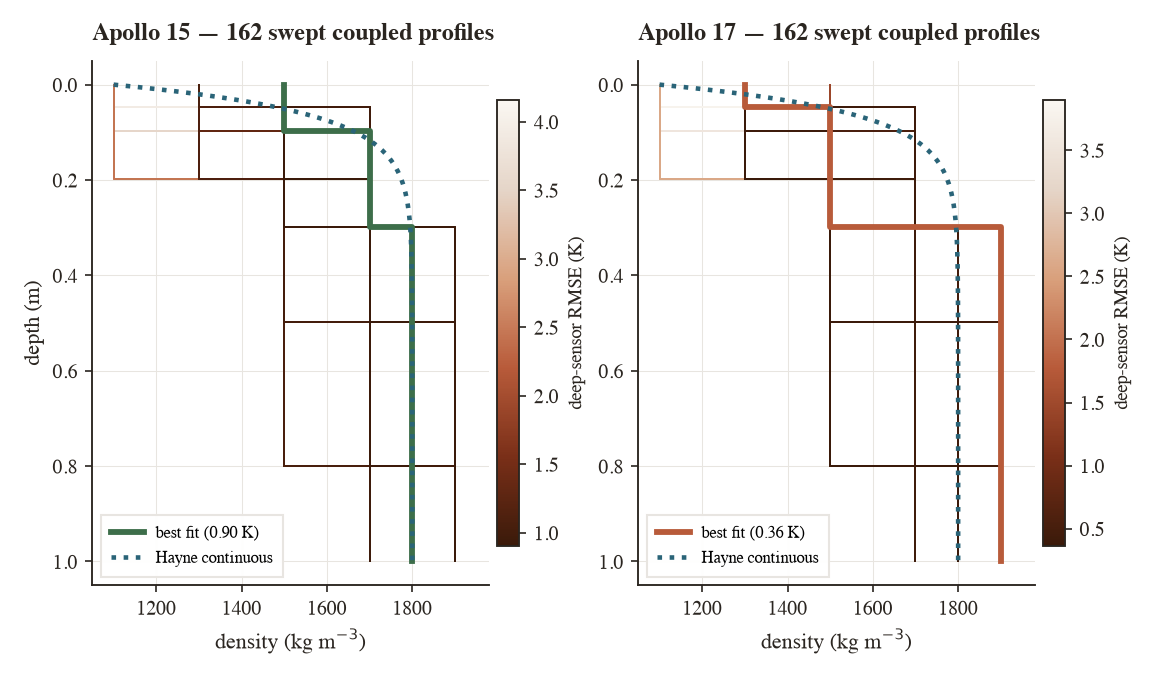

In [23]:
# Density sweep: every swept coupled profile, coloured by how well it fits
import json, numpy as np, matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from lunar.plotting.style import (JGR_FULL, C_A15, C_A17, C_HAYNE, C_GRID,
                                  ANTH_SEQ, fmt_axis, assert_no_overlap)
from lunar.properties import density_hayne

_ds = json.loads((ROOT/"results"/"aogs_density_study.json").read_text())["runs"]
z = np.linspace(0, 1.0, 400)
SITE = {"A15": C_A15, "A17": C_A17}
fig, axes = plt.subplots(1, 2, figsize=(JGR_FULL, 4.3), constrained_layout=True)
for ax, sk in zip(axes, ("A15", "A17")):
    recs = [r for r in _ds if r["site"] == sk and r["branch"] == "coupled"
            and r["rho"] != "hayne"]
    rmse = np.array([r["rmse_K"] for r in recs])
    cmap = ANTH_SEQ.reversed()                       # best = dark, poor = faded
    norm = Normalize(rmse.min(), np.percentile(rmse, 85))
    for i in np.argsort(rmse)[::-1]:                 # best drawn last (on top)
        r = recs[i]; r1, r2, r3 = r["rho"]; z1, z2 = r["z1_m"], r["z2_m"]
        prof = np.where(z < z1, r1, np.where(z < z2, r2, r3))
        ax.step(prof, z, where="post", color=cmap(norm(rmse[i])), lw=0.8, alpha=0.6)
    b = min(recs, key=lambda r: r["rmse_K"])
    r1, r2, r3 = b["rho"]; z1, z2 = b["z1_m"], b["z2_m"]
    ax.step(np.where(z < z1, r1, np.where(z < z2, r2, r3)), z, where="post",
            color=SITE[sk], lw=2.8, label=f"best fit ({b['rmse_K']:.2f} K)")
    ax.plot(density_hayne(z), z, ":", color=C_HAYNE, lw=2.2, label="Hayne continuous")
    ax.set_xlim(1050, 1980); ax.invert_yaxis()
    fmt_axis(ax, xlabel=r"density (kg m$^{-3}$)",
             ylabel="depth (m)" if sk == "A15" else "",
             title=f"Apollo {sk[1:]} — 162 swept coupled profiles")
    ax.legend(loc="lower left", fontsize=8, frameon=True, edgecolor=C_GRID)
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.85, pad=0.02).set_label(
        "deep-sensor RMSE (K)", fontsize=9)
    fig.canvas.draw(); assert_no_overlap(ax)
plt.show()

## 18. The density search space — every density profile we evaluated

The complete menu of 3-layer density structures the sweep considers: the 18 ordered density triples ($\rho_1\le\rho_2\le\rho_3$) $\times$ the 9 $(z_1,z_2)$ boundary pairs = 162 profiles, coloured by the surface density $\rho_1$ and shown against the continuous Hayne $\rho(z)$. The x-ticks are the exact densities chosen for each layer. (§9 / §17 then score how each one fits.)

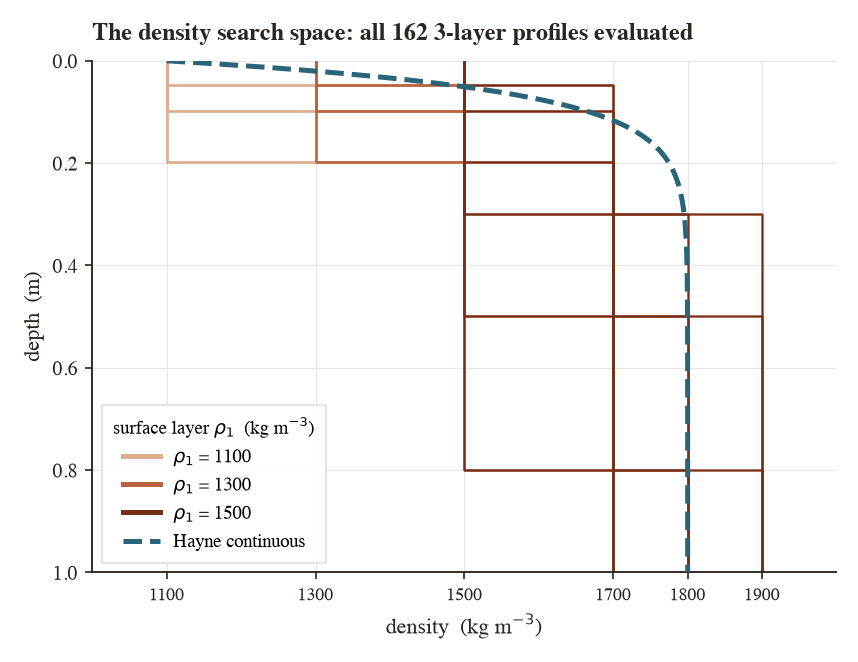

In [24]:
# The density search space: every 3-layer density profile the sweep evaluates,
# organised by the surface-layer density rho_1 (the layer that carries the
# leverage). Branch-agnostic -- cp and coupled share the same density geometry;
# the x-ticks are the exact densities chosen for rho1/rho2/rho3.
import json, itertools
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from lunar._bootstrap import find_repo_root
from lunar.plotting.style import (JGR_HALF, C_HAYNE, C_GRID, ANTH_SEQ,
                                   fmt_axis, assert_no_overlap)
from lunar.properties import density_hayne

ROOT = find_repo_root()
_meta = json.loads((ROOT/"results"/"aogs_density_study.json").read_text())["meta"]
Z1G, Z2G = _meta["z1_grid"], _meta["z2_grid"]
RHO1, RHO2, RHO3 = _meta["rho1"], _meta["rho2"], _meta["rho3"]

# the exact ordered density triples the study swept (rho1 <= rho2 <= rho3),
# each combined with every (z1, z2) boundary pair
triples = [(r1, r2, r3) for r1 in RHO1 for r2 in RHO2 for r3 in RHO3
           if r1 <= r2 <= r3]
n_cfg = len(triples) * len(Z1G) * len(Z2G)
RHO1_COLOR = {r: ANTH_SEQ(x) for r, x in zip(RHO1, (0.35, 0.58, 0.82))}
CHOSEN_RHO = sorted(set(RHO1) | set(RHO2) | set(RHO3))

def _rho_step(z, z1, z2, r1, r2, r3):
    return np.where(z < z1, r1, np.where(z < z2, r2, r3))

z = np.linspace(0.0, 1.0, 500)
fig, ax = plt.subplots(figsize=(JGR_HALF, 4.2), constrained_layout=True)
for (r1, r2, r3), z1, z2 in itertools.product(triples, Z1G, Z2G):
    ax.step(_rho_step(z, z1, z2, r1, r2, r3), z, where="post",
            color=RHO1_COLOR[r1], lw=0.7, alpha=0.35)
ax.plot(density_hayne(z), z, "--", color=C_HAYNE, lw=2.4, zorder=6)
ax.invert_yaxis()
handles = [Line2D([0], [0], color=RHO1_COLOR[r], lw=2.4, label=rf"$\rho_1$ = {int(r)}")
           for r in RHO1] + \
          [Line2D([0], [0], color=C_HAYNE, lw=2.4, ls="--", label="Hayne continuous")]
fmt_axis(ax, xlabel=r"density  (kg m$^{-3}$)", ylabel="depth  (m)",
         title=f"The density search space: all {n_cfg} 3-layer profiles evaluated")
leg = ax.legend(handles=handles, frameon=True, edgecolor=C_GRID, framealpha=0.97,
                loc="lower left", fontsize=9, title=r"surface layer $\rho_1$  (kg m$^{-3}$)")
leg.get_title().set_fontsize(9)
ax.set_xlim(1000, 2000); ax.set_ylim(1.0, 0.0)
ax.set_xticks(CHOSEN_RHO)
ax.set_xticklabels([str(int(v)) for v in CHOSEN_RHO], fontsize=8.5)
fig.canvas.draw(); assert_no_overlap(ax)
plt.show()


## 18. How the shadowing algorithm works

The DEM feeds **one** thing — the skyline. Then at each moment we ask *"is the Sun above it?"*

1. **Ray-trace the horizon** (`horizon_profile`): from the site cast 90 rays; along each, sample the DEM outward, subtract the curvature drop $r^2/2R$, and keep the max elevation angle $\to$ the horizon $\theta_{\rm h}$ per azimuth (panel 1; the green skyline in panel 2).
2. **Track the Sun** (`sun_track`): its elevation and azimuth over the lunation (declination 0).
3. **Block the beam** (`shadowed_insolation`): keep the insolation where Sun elevation $>\theta_{\rm h}$ at the Sun's azimuth, else set it to **0** (the plum arc in panel 2 $\to$ the zeroed slices in panel 3).
4. That shadowed forcing goes straight to the solver — the DEM's *entire* influence is those zeroed low-Sun slices.

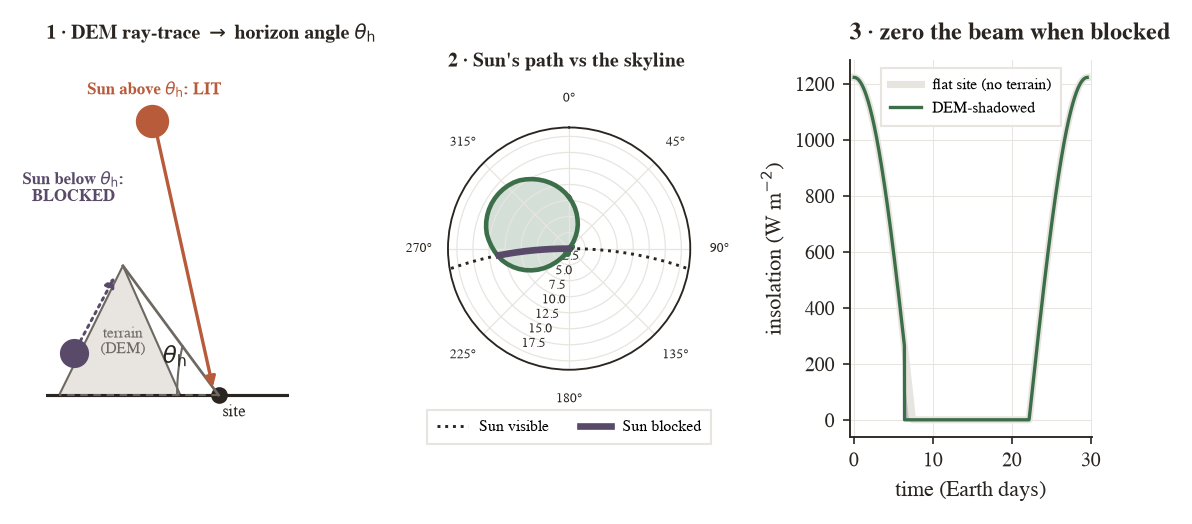

In [25]:
# Diagram: the shadowing algorithm in three steps (real A15 data in panels 2-3)
import sys, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
sys.path.insert(0, str(ROOT/"pipeline"/"compute"/"aogs"))
import s1_sensitivity as base
from lunar.config import SITES, DT_STEP
from lunar.solver import periodic_time_grid
from lunar.plotting.style import (JGR_FULL, C_A15, C_CHAR, C_DIM, C_GRID, C_CORAL,
                                  C_PLUM, fmt_axis, assert_no_overlap)
s = SITES["A15"]; dem, ppd = base.load_dem(); t = periodic_time_grid(DT_STEP)
az, hor = base.horizon_profile(dem, ppd, s["lat"], s["lon"])
elev, A = base.sun_track(s["lat"], t)
S_std = base.standard_insolation(s["lat"], t); S_sh = base.shadowed_insolation(s["lat"], t, az, hor)
days = np.asarray(t)/86400.0
fig = plt.figure(figsize=(JGR_FULL, 3.5))
ax1 = fig.add_subplot(1,3,1); ax2 = fig.add_subplot(1,3,2, projection="polar"); ax3 = fig.add_subplot(1,3,3)
ax1.set_xlim(-5.4,2.2); ax1.set_ylim(-0.55,4.4); ax1.axis("off")
ax1.plot([-5.4,2.2],[0,0], color=C_CHAR, lw=1.5)
ax1.add_patch(mpatches.Polygon([(-5.0,0),(-3.0,1.7),(-1.2,0)], closed=True, fc=C_GRID, ec=C_DIM, lw=1))
ax1.text(-3.0,0.55,"terrain\n(DEM)", ha="center", fontsize=7.5, color=C_DIM)
ax1.plot(0,0,"o", color=C_CHAR, ms=7); ax1.text(0.12,-0.28,"site", fontsize=8, color=C_CHAR)
ax1.plot([0,-5.0],[0,0], color=C_DIM, ls=(0,(4,3)), lw=0.9); ax1.plot([0,-3.0],[0,1.7], color=C_DIM, lw=1.3)
th=np.linspace(np.pi, np.pi-np.arctan2(1.7,3.0),30); ax1.plot(1.3*np.cos(th),1.3*np.sin(th), color=C_DIM, lw=1)
ax1.text(-1.75,0.42, r"$\theta_{\rm h}$", fontsize=11, color=C_CHAR)
ax1.plot(-2.1,3.6,"o", color=C_CORAL, ms=15)
ax1.annotate("",(-0.15,0.05),(-1.95,3.45), arrowprops=dict(arrowstyle="-|>", color=C_CORAL, lw=1.6))
ax1.text(-2.0,3.95,"Sun above $\\theta_{\\rm h}$: LIT", ha="center", fontsize=8, color=C_CORAL, fontweight="bold")
ax1.plot(-4.55,0.55,"o", color=C_PLUM, ms=13)
ax1.annotate("",(-3.2,1.6),(-4.4,0.66), arrowprops=dict(arrowstyle="-|>", color=C_PLUM, lw=1.4, ls=":"))
ax1.text(-4.55,2.55,"Sun below $\\theta_{\\rm h}$:\nBLOCKED", ha="center", fontsize=8, color=C_PLUM, fontweight="bold")
ax1.set_title("1 · DEM ray-trace $\\to$ horizon angle $\\theta_{\\rm h}$", fontsize=9.5)
azr=np.radians(az)
ax2.plot(np.append(azr,azr[0]), np.append(hor,hor[0]), color=C_A15, lw=2.2)
ax2.fill(np.append(azr,azr[0]), np.append(hor,hor[0]), color=C_A15, alpha=0.22)
rmax=1.35*hor.max(); vis=(elev>=0)&(elev<=rmax); hor_at=np.interp(A,az,hor,period=360)
clear=vis&(elev>hor_at); blocked=vis&(elev<=hor_at)
ax2.plot(np.radians(np.where(clear,A,np.nan)), np.where(clear,elev,np.nan), color=C_CHAR, lw=1.4, ls=":", label="Sun visible")
ax2.plot(np.radians(np.where(blocked,A,np.nan)), np.where(blocked,elev,np.nan), color=C_PLUM, lw=3.2, label="Sun blocked")
ax2.set_theta_zero_location("N"); ax2.set_theta_direction(-1); ax2.set_rmax(rmax)
ax2.set_rlabel_position(205); ax2.tick_params(labelsize=6.5)
ax2.set_title("2 · Sun's path vs the skyline", fontsize=9.5, pad=12)
ax2.legend(loc="lower center", bbox_to_anchor=(0.5,-0.34), fontsize=7.5, frameon=True, edgecolor=C_GRID, ncols=2)
ax3.plot(days,S_std, color=C_GRID, lw=3.4, label="flat site (no terrain)")
ax3.plot(days,S_sh, color=C_A15, lw=1.6, label="DEM-shadowed")
blk=(S_std>1)&(S_sh<=1); ax3.fill_between(days,0,S_std, where=blk, color=C_PLUM, alpha=0.35, lw=0)
fmt_axis(ax3, xlabel="time (Earth days)", ylabel="insolation (W m$^{-2}$)", title="3 · zero the beam when blocked")
ax3.legend(loc="upper center", fontsize=7.5, frameon=True, edgecolor=C_GRID); ax3.margins(x=0.02)
fig.tight_layout(w_pad=1.5); fig.canvas.draw(); assert_no_overlap(ax3)
plt.show()

### 18a. Step 1 in detail — the ray-trace that builds the horizon

One ray (A15, azimuth 304°, NW) marched over the DEM. Each sample's elevation angle is
$\arctan[(h(r)-h_0-r^2/2R)/r]$ and the **horizon is the maximum**. Here the **near crater
rim at 1 km wins (14°)**, while the **far wall 45 km out — though +1.2 km tall — subtends
only 0.8°** (distance + curvature shrink its angle) and stays below the horizon.

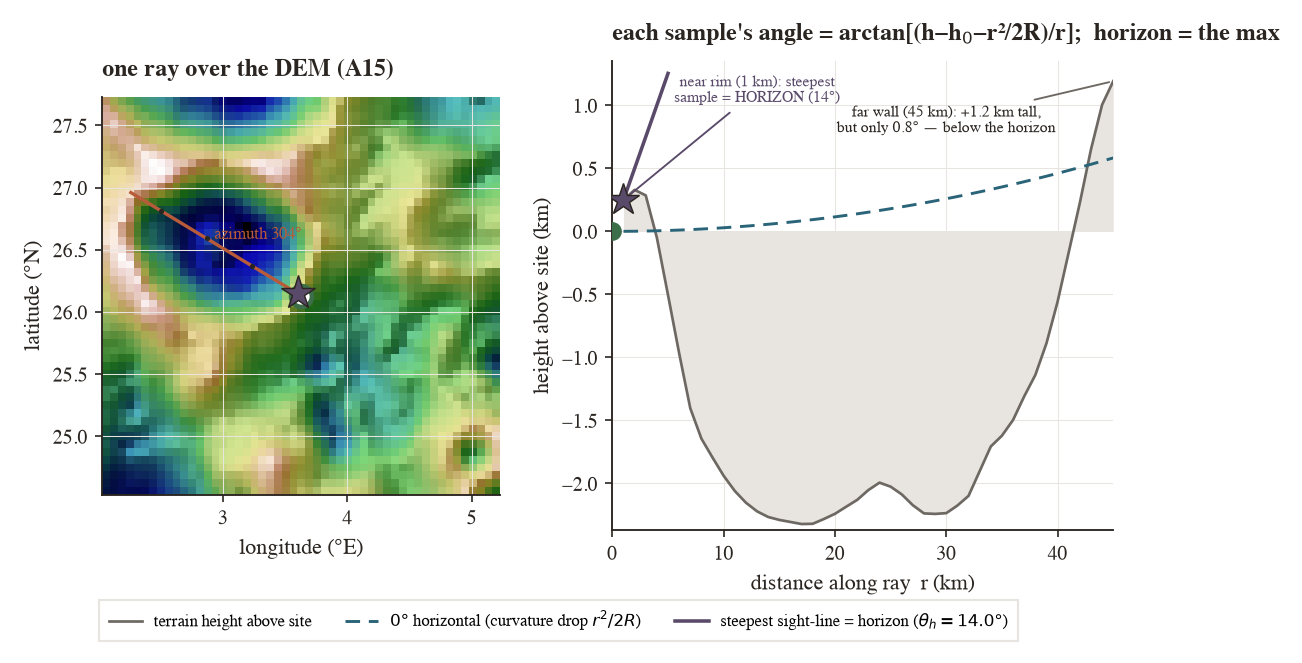

In [26]:
# Ray-trace detail: how the horizon angle is formed along one ray (real A15)
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import sys; sys.path.insert(0, str(ROOT/"pipeline"/"compute"/"aogs"))
import s1_sensitivity as base
from lunar.config import SITES
from lunar.plotting.style import (JGR_FULL, C_A15, C_CHAR, C_DIM, C_GRID, C_CORAL,
                                  C_PLUM, C_TEAL, fmt_axis, legend_below)
s = SITES["A15"]; lat0, lon0 = s["lat"], s["lon"]; R = 1737.4
dem, ppd = base.load_dem()
az, hor = base.horizon_profile(dem, ppd, lat0, lon0); a_deg = float(az[np.argmax(hor)])
dr = min(1.0, 2*np.pi*R/360.0/ppd); r = np.arange(dr, 45.0+dr, dr); a = np.radians(a_deg)
dlat = np.degrees((r/R)*np.cos(a)); dlon = np.degrees((r/R)*np.sin(a)/max(np.cos(np.radians(lat0)),1e-6))
h0 = float(base._dem_sample(dem, ppd, lat0, lon0))
hh = np.asarray(base._dem_sample(dem, ppd, lat0+dlat, lon0+dlon))
drop = r**2/(2.0*R); ang = np.degrees(np.arctan2(hh-h0-drop, r)); ih = int(np.argmax(ang))
far = int(20+np.argmax((hh-h0)[r>20]))
fig,(axm,axc)=plt.subplots(1,2,figsize=(JGR_FULL,3.9),gridspec_kw={"width_ratios":[1,1.15]},constrained_layout=True)
half=1.6
r0=int((90-lat0-half)*ppd); r1=int((90-lat0+half)*ppd); c0=int((lon0+180-half)*ppd); c1=int((lon0+180+half)*ppd)
crop=dem[r0:r1,c0:c1]*base.DEM_SCALE_KM
shaded=LightSource(azdeg=315,altdeg=35).shade(crop,cmap=plt.get_cmap("gist_earth"),blend_mode="soft",vert_exag=25)
axm.imshow(shaded,extent=(lon0-half,lon0+half,lat0-half,lat0+half),origin="upper")
axm.plot(lon0+dlon,lat0+dlat,"-",color=C_CORAL,lw=1.6); axm.plot(lon0+dlon[::12],lat0+dlat[::12],".",color=C_CHAR,ms=3)
axm.plot(lon0,lat0,"o",color="white",mec=C_A15,mew=2.2,ms=10)
axm.plot(lon0+dlon[ih],lat0+dlat[ih],"*",color=C_PLUM,ms=17,mec=C_CHAR,mew=0.7)
axm.annotate(f"azimuth {a_deg:.0f}°",(lon0+dlon[len(r)//2],lat0+dlat[len(r)//2]),fontsize=8,color=C_CORAL,ha="left",va="bottom")
fmt_axis(axm,xlabel="longitude (°E)",ylabel="latitude (°N)",title="one ray over the DEM (A15)")
axc.fill_between(r,0,hh-h0,color=C_GRID,lw=0,zorder=1); axc.plot(r,hh-h0,color=C_DIM,lw=1.3,zorder=2,label="terrain height above site")
axc.plot(r,drop,color=C_TEAL,lw=1.4,ls=(0,(5,3)),zorder=2,label=r"$0°$ horizontal (curvature drop $r^2/2R$)")
sight=np.tan(np.radians(ang[ih]))*r+drop; _m=sight<1.32
axc.plot(r[_m],sight[_m],color=C_PLUM,lw=1.7,zorder=3,label=f"steepest sight-line = horizon ($\\theta_h={ang[ih]:.1f}°$)")
axc.plot(r[ih],hh[ih]-h0,"*",color=C_PLUM,ms=16,mec=C_CHAR,mew=0.7,zorder=4); axc.plot(0,0,"o",color=C_A15,ms=8,zorder=4)
axc.annotate(f"near rim ({r[ih]:.0f} km): steepest\nsample = HORIZON ({ang[ih]:.0f}°)",(r[ih],hh[ih]-h0),(13,1.12),fontsize=7.5,color=C_PLUM,ha="center",arrowprops=dict(arrowstyle="-",color=C_PLUM,lw=0.9),va="center")
axc.annotate(f"far wall ({r[far]:.0f} km): +{hh[far]-h0:.1f} km tall,\nbut only {ang[far]:.1f}° — below the horizon",(r[far],hh[far]-h0),(30,0.88),fontsize=7.5,color=C_CHAR,ha="center",arrowprops=dict(arrowstyle="-",color=C_DIM,lw=0.9),va="center")
axc.set_xlim(0,r.max()); axc.set_ylim(min(0,(hh-h0).min())-0.05,1.35)
fmt_axis(axc,xlabel="distance along ray  r (km)",ylabel="height above site (km)",title="each sample's angle = arctan[(h−h$_0$−r²/2R)/r];  horizon = the max")
fig.canvas.draw(); legend_below(fig,*axc.get_legend_handles_labels(),ncols=3,fontsize=8); plt.show()

### 18b. What kind of algorithm is this, and is it the best?

A **horizon-based ray-caster** ("horizon mapping") — the standard method for terrain solar
illumination, the same family used by rigorous lunar-illumination models (e.g. Mazarico et al. 2011).

**Correct core, simplified implementation.** Adequate for a 2-borehole "is shadowing first-order?"
question; a high-fidelity product would add: finer azimuth than 90 rays (4°), sub-sample peak
refinement, the site's own local slope/aspect, and full terrain **view-factor radiosity** for the
re-radiated/scattered flux (vs. the current bulk $(1-\mathrm{SVF})$ approximation) — plus the finer
DEM (SLDEM 59 m). For a whole-DEM shadow map you'd use the Dozier–Frew (1990) horizon sweep instead
of brute ray-marching; for 2 points brute is simpler and fine. None of these change the density
result — they tighten the shadowing/terrain-radiation numbers.

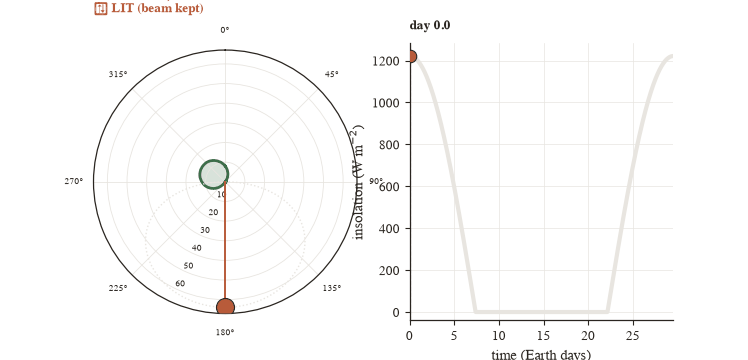

In [27]:
# The shadowing animation (also saved at results/anim/shadowing_algorithm.gif)
from IPython.display import Image as _Img, display
display(_Img(filename=str(ROOT/"results"/"anim"/"shadowing_algorithm.gif")))